In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Score Generation

In [ ]:
#!/usr/bin/env python
# coding: utf-8
%%writefile pipeline_train_fuse_detect.py


import os
import re
import ast
import math
import json
import argparse
import random
import warnings
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity

import joblib
from tqdm import tqdm

warnings.filterwarnings("ignore")

# =========================================================
# 0) Configuration
# =========================================================
@dataclass
class CFG:
    random_state: int = 42
    out_dir: str = "./outputs"
    use_gpu: bool = True

    # Text column candidates
    intro_candidates: Tuple[str, ...] = ("intro", "intro_text")
    body_candidates: Tuple[str, ...] = ("body", "body_text")
    concl_candidates: Tuple[str, ...] = ("conclusion", "conclusion_text")
    source_col_candidates: Tuple[str, ...] = ("source",)

    # Document chunking
    max_len: int = 512
    stride: int = 256
    max_chunks: int = 12
    doc_batch_size: int = 4

    # fusion / cv
    kfold: int = 5
    C_grid: Tuple[float, ...] = (0.03, 0.1, 0.3, 1.0)

    # final alpha
    alpha_grid: Tuple[float, ...] = tuple([i / 50.0 for i in range(0, 51)])  # 0..1
    guard_eps: float = 0.003  # fusion3 significantly worse than text then fallback to text

    # PPL language model (only used if PPL columns are missing)
    ppl_lm_name: str = "gpt2"
    ppl_max_ctx: int = 1024
    ppl_stride: int = 256
    ppl_token_budget: int = 2048
    ppl_use_gpu: bool = True

cfg = CFG()


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> str:
    if cfg.use_gpu and torch.cuda.is_available():
        return "cuda"
    return "cpu"


def robust_read_csv(path: str) -> pd.DataFrame:
    for enc in ["utf-8", "utf-8-sig", "gb18030", "gbk", "latin1"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[read] CSV encoding={enc}")
            return df
        except Exception:
            continue
    # Fallback ignoring bad characters
    return pd.read_csv(path, encoding="latin1", errors="ignore")


def smart_read_table(path: str) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(path, engine="openpyxl")
    if ext == ".csv":
        return robust_read_csv(path)
    # unknown: try excel then csv
    try:
        return pd.read_excel(path, engine="openpyxl")
    except Exception:
        return robust_read_csv(path)


def pick_col(df: pd.DataFrame, candidates: Tuple[str, ...], required=True) -> Optional[str]:
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"Cannot find any of these columns: {candidates}")
    return None


def make_label(df: pd.DataFrame, source_col: str) -> np.ndarray:
    return (df[source_col].astype(str).str.lower() != "human").astype(int).values


def build_full_text(df: pd.DataFrame, intro_col: str, body_col: str, concl_col: str) -> List[str]:
    def s(x):
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return ""
        return str(x)
    return (df[intro_col].apply(s) + "\n\n" + df[body_col].apply(s) + "\n\n" + df[concl_col].apply(s)).tolist()


# =========================================================
# 1) R-detect + chunk pooling
# =========================================================
class DocDataset(Dataset):
    def __init__(self, texts: List[str], tokenizer: AutoTokenizer):
        self.texts = texts
        self.tok = tokenizer

    def __len__(self):
        return len(self.texts)

    def _chunks(self, text: str) -> List[List[int]]:
        t = "" if text is None else str(text).strip()
        if not t:
            ids = self.tok.encode(" ", add_special_tokens=True)
            return [ids[: cfg.max_len]]

        # Use encode, no "too long" warning
        ids = self.tok.encode(t, add_special_tokens=True, truncation=False)

        chunks = []
        start = 0
        n = len(ids)
        while start < n:
            end = min(start + cfg.max_len, n)
            piece = ids[start:end]
            if len(piece) < 16:
                break
            chunks.append(piece)
            if end >= n:
                break
            start += cfg.stride

        if not chunks:
            chunks = [ids[: cfg.max_len]]
        return chunks[: cfg.max_chunks]

    def __getitem__(self, idx):
        return self._chunks(self.texts[idx])


def collate_doc(batch, pad_id: int):
    flat_ids, flat_attn, doc_ptr = [], [], []
    cursor = 0
    for chunks in batch:
        s = cursor
        for ids in chunks:
            ids = ids[: cfg.max_len]
            pad_len = cfg.max_len - len(ids)
            flat_ids.append(ids + [pad_id] * pad_len)
            flat_attn.append([1] * len(ids) + [0] * pad_len)
            cursor += 1
        e = cursor
        doc_ptr.append((s, e))
    return (
        torch.tensor(flat_ids, dtype=torch.long),
        torch.tensor(flat_attn, dtype=torch.long),
        doc_ptr,
    )


def _ai_prob_from_logits(logits: torch.Tensor) -> torch.Tensor:
    if logits.dim() == 1:
        return torch.sigmoid(logits)
    if logits.size(-1) == 1:
        return torch.sigmoid(logits.squeeze(-1))
    probs = torch.softmax(logits, dim=-1)
    return probs[:, 0]


from transformers import AutoModel

class ChunkPoolingRDetect(nn.Module):

    def __init__(self, model_name: str):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size
        self.head = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask, doc_ptr):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        # Take CLS vector
        cls = out.last_hidden_state[:, 0, :]   # [n_chunks, hidden]
        chunk_logits = self.head(cls).squeeze(-1)  # [n_chunks]
        chunk_prob = torch.sigmoid(chunk_logits)

        doc_prob = []
        for s, e in doc_ptr:
            doc_prob.append(chunk_prob[s:e].mean())
        return torch.stack(doc_prob, dim=0)

class ChunkPoolingSeqCls(nn.Module):
    """
    Use AutoModelForSequenceClassification for chunk pooling:
    each chunk gets logits -> convert to AI probability -> doc takes mean
    """
    def __init__(self, model_name: str):
        super().__init__()
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name)

    def forward(self, input_ids, attention_mask, doc_ptr):
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        logits = out.logits  # [n_chunks, 2] or [n_chunks,1] or [n_chunks]
        chunk_prob = _ai_prob_from_logits(logits).view(-1)  # [n_chunks]

        doc_prob = []
        for s, e in doc_ptr:
            doc_prob.append(chunk_prob[s:e].mean())
        return torch.stack(doc_prob, dim=0)


@torch.no_grad()
def predict_text_scores(texts: List[str], tok, model, device: str) -> np.ndarray:
    ds = DocDataset(texts, tok)
    dl = DataLoader(ds, batch_size=cfg.doc_batch_size, shuffle=False,
                    collate_fn=lambda b: collate_doc(b, tok.pad_token_id))
    model.eval()
    out = []
    for input_ids, attn, doc_ptr in tqdm(dl, desc="score_text", leave=False):
        input_ids = input_ids.to(device)
        attn = attn.to(device)
        prob = model(input_ids, attn, doc_ptr).detach().cpu().numpy()
        out.extend(prob.tolist())
    return np.array(out, dtype=float)


# def load_text_model(text_model_path: str):
#     ckpt = torch.load(text_model_path, map_location="cpu")

#     model_name = ckpt.get("text_model_name") or ckpt.get("model_name")
#     if model_name is None:
#         raise ValueError("ckpt missing model_name/text_model_name")

#     tok_name = ckpt.get("tokenizer_name", model_name)

#     tok = AutoTokenizer.from_pretrained(tok_name, use_fast=True)
#     if tok.pad_token is None:
#         tok.pad_token = tok.eos_token if tok.eos_token else tok.unk_token

#     sd = ckpt["state_dict"]

#     # ✅ Determine: if state_dict has backbone./head. prefix => HC3-RDetect
#     is_hc3_rdetect = any(k.startswith("backbone.") for k in sd.keys())

#     if is_hc3_rdetect:
#         model = ChunkPoolingRDetect(model_name)
#         model.load_state_dict(sd, strict=True)
#         model_type = "hc3_rdetect(backbone+head)"
#     else:
#         # ✅ Otherwise load as seqcls / OpenAI-D style
#         model = ChunkPoolingSeqCls(model_name)
#         # Note: load into seqcls internal model
#         model.model.load_state_dict(sd, strict=True)
#         model_type = "seqcls(OpenAI-D etc.)"

#     print(f"[load_text_model] type={model_type} | model_name={model_name}")
#     return tok, model, ckpt
import torch
import torch.nn as nn
from transformers import AutoTokenizer

class LimitedToxic(nn.Module):
    """Hard-truncate wrapper used for toxic limitation."""
    def __init__(self, base_model: nn.Module, max_len: int = 128):
        super().__init__()
        self.base_model = base_model
        self.max_len = int(max_len)

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, **kwargs):
        if input_ids is not None:
            input_ids = input_ids[:, : self.max_len]
        if attention_mask is not None:
            attention_mask = attention_mask[:, : self.max_len]
        if token_type_ids is not None:
            token_type_ids = token_type_ids[:, : self.max_len]
        return self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            **kwargs
        )

def _strip_prefix(sd: dict, prefix: str) -> dict:
    """Remove a prefix from all keys if present."""
    if not any(k.startswith(prefix) for k in sd.keys()):
        return sd
    plen = len(prefix)
    return {k[plen:]: v for k, v in sd.items() if k.startswith(prefix)}

def load_text_model(text_model_path: str):
    ckpt = torch.load(text_model_path, map_location="cpu")

    model_name = ckpt.get("text_model_name") or ckpt.get("model_name")
    if model_name is None:
        raise ValueError("ckpt missing model_name/text_model_name")

    tok_name = ckpt.get("tokenizer_name", model_name)

    tok = AutoTokenizer.from_pretrained(tok_name, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token if tok.eos_token else tok.unk_token

    sd = ckpt["state_dict"]

    # 1) HC3-RDetect
    is_hc3_rdetect = any(k.startswith("backbone.") for k in sd.keys())
    if is_hc3_rdetect:
        model = ChunkPoolingRDetect(model_name)
        model.load_state_dict(sd, strict=True)
        model_type = "hc3_rdetect(backbone+head)"
        print(f"[load_text_model] type={model_type} | model_name={model_name}")
        return tok, model, ckpt

    # 2) SeqCls/OpenAI-D style
    model = ChunkPoolingSeqCls(model_name)

    # 2.1) Compatibility: LimitedToxic wrapper saved with base_model.* prefix
    max_len = ckpt.get("max_len", None)
    has_base_prefix = any(k.startswith("base_model.") for k in sd.keys())
    if has_base_prefix:
        sd = _strip_prefix(sd, "base_model.")
        model_type = "seqcls(limited toxic: stripped base_model.*)"
    else:
        model_type = "seqcls(OpenAI-D etc.)"

    # 2.2) Strict load first (if still fails, give a friendlier error)
    try:
        model.model.load_state_dict(sd, strict=True)
    except RuntimeError as e:
        # Give clearer diagnosis: usually model name mismatch or incorrect save fields
        raise RuntimeError(
            f"Failed to load state_dict into ChunkPoolingSeqCls(model_name={model_name}).\n"
            f"Tips:\n"
            f"  - Check ckpt['model_name'] matches the backbone used when saving.\n"
            f"  - If keys have a different prefix, ensure stripping is correct.\n"
            f"  - First 10 keys in sd: {list(sd.keys())[:10]}\n"
        ) from e

    # 2.3) If ckpt contains max_len, wrap internal backbone with LimitedToxic
    if max_len is not None:
        model.model = LimitedToxic(model.model, max_len=int(max_len))
        model_type += f" + LimitedToxic(max_len={int(max_len)})"

    print(f"[load_text_model] type={model_type} | model_name={model_name}")
    return tok, model, ckpt




# =========================================================
# 2) Features: Struct / PPL / Style (prefer existing columns if present)
# =========================================================
def parse_numeric_value(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str) and value.startswith('[') and value.endswith(']'):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list) and len(parsed) > 0:
                return float(parsed[0])
            return np.nan
        except:
            return np.nan
    try:
        return float(value)
    except:
        return np.nan


def parse_dict(value):
    if pd.isna(value) or not isinstance(value, str):
        return {}
    try:
        return ast.literal_eval(value)
    except:
        return {}


# ---------- Struct: prefer existing columns, otherwise proxy compute ----------
_STOPWORDS = set(
    """
a an the and or but if then else when while for to of in on at by with without from as is are was were be been being
this that these those it its i you he she they we my your his her their our
not no do does did doing done can could may might will would shall should
""".split()
)
_word_re = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")

def tokenize_words(text: str) -> List[str]:
    return _word_re.findall(str(text).lower())

def split_sents(text: str) -> List[str]:
    t = str(text)
    if not t.strip():
        return []
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", t) if s.strip()]

def brunet_index(words: List[str], a: float = 0.165) -> float:
    N = len(words)
    if N == 0:
        return np.nan
    V = len(set(words))
    if V == 0:
        return np.nan
    return float((N ** (V ** (-a))))

def readability_proxy(text: str) -> float:
    words = tokenize_words(text)
    sents = split_sents(text)
    if len(words) == 0 or len(sents) == 0:
        return np.nan
    avg_sent_len = len(words) / len(sents)
    avg_word_len = np.mean([len(w) for w in words]) if words else np.nan
    punct = sum(1 for ch in str(text) if ch in ",;:—-()")
    punct_rate = punct / max(len(str(text)), 1)
    return float(0.6 * avg_sent_len + 0.4 * avg_word_len + 20.0 * punct_rate)

def formality_proxy(text: str) -> float:
    words = tokenize_words(text)
    if len(words) == 0:
        return np.nan
    stop_cnt = sum(1 for w in words if w in _STOPWORDS)
    return float(stop_cnt / len(words))

def compute_struct_measures_if_missing(df: pd.DataFrame, intro_col: str, body_col: str, concl_col: str) -> pd.DataFrame:
    need = [
        "intro_readability_score","body_readability_score","conclusion_readability_score",
        "intro_brunet_index","body_brunet_index","conclusion_brunet_index",
        "intro_formality_score","body_formality_score","conclusion_formality_score",
    ]
    if all(c in df.columns for c in need):
        out = pd.DataFrame(index=df.index)
        for c in need:
            out[c] = df[c].apply(parse_numeric_value)
        return out

    # Otherwise compute via proxy
    out = pd.DataFrame(index=df.index)
    for seg, col in [("intro", intro_col), ("body", body_col), ("conclusion", concl_col)]:
        texts = df[col].astype(str).fillna("")
        out[f"{seg}_readability_score"] = texts.apply(readability_proxy)
        out[f"{seg}_brunet_index"] = texts.apply(lambda x: brunet_index(tokenize_words(x)))
        out[f"{seg}_formality_score"] = texts.apply(formality_proxy)
    return out

def structural_delta(struct_df: pd.DataFrame, wIB=0.505, wBC=0.495) -> pd.DataFrame:
    out = pd.DataFrame(index=struct_df.index)
    for cols, name in [
        (("intro_readability_score", "body_readability_score", "conclusion_readability_score"), "readability_delta"),
        (("intro_brunet_index", "body_brunet_index", "conclusion_brunet_index"), "ttr_delta"),
        (("intro_formality_score", "body_formality_score", "conclusion_formality_score"), "formality_delta"),
    ]:
        I = struct_df[cols[0]].values.astype(float)
        B = struct_df[cols[1]].values.astype(float)
        C = struct_df[cols[2]].values.astype(float)
        out[name] = wIB * np.abs(I - B) + wBC * np.abs(B - C)
    return out


# ---------- PPL: prefer existing columns, otherwise gpt2 sliding window ----------
@torch.no_grad()
def ppl_sliding_window_ids(token_ids: List[int], model, max_ctx=1024, stride=256, device="cpu") -> float:
    ids = torch.tensor(token_ids, dtype=torch.long)
    n = ids.numel()
    if n < 4:
        return np.nan

    neg_log_liks = []
    prev_end = 0
    for begin in range(0, n, stride):
        end = min(begin + max_ctx, n)
        trg_len = end - prev_end
        inp = ids[begin:end].unsqueeze(0).to(device)
        labels = inp.clone()
        labels[:, :-trg_len] = -100
        out = model(inp, labels=labels)
        neg_log_liks.append(out.loss.item() * trg_len)
        prev_end = end
        if end == n:
            break

    if len(neg_log_liks) == 0 or prev_end <= 0:
        return np.nan
    nll = sum(neg_log_liks) / prev_end
    return float(math.exp(nll))

def compute_ppl_means_if_missing(df: pd.DataFrame, intro_col: str, body_col: str, concl_col: str) -> pd.DataFrame:
    need_cols = ["intro_mean", "body_mean", "conclusion_mean"]
    if all(c in df.columns for c in need_cols):
        out = pd.DataFrame(index=df.index)
        for c in need_cols:
            out[c] = df[c].apply(parse_numeric_value)
        return out

    device = "cuda" if (cfg.ppl_use_gpu and torch.cuda.is_available()) else "cpu"
    tok = AutoTokenizer.from_pretrained(cfg.ppl_lm_name, use_fast=True)
    lm = AutoModelForCausalLM.from_pretrained(cfg.ppl_lm_name).to(device)
    lm.eval()

    out = pd.DataFrame(index=df.index)
    for seg, col in [("intro", intro_col), ("body", body_col), ("conclusion", concl_col)]:
        vals = []
        texts = df[col].astype(str).fillna("").tolist()
        for t in tqdm(texts, desc=f"PPL({seg})", leave=False):
            tt = str(t).strip()
            if not tt:
                vals.append(np.nan)
                continue
            ids = tok.encode(tt, add_special_tokens=False, truncation=False)
            ids = ids[: min(len(ids), cfg.ppl_token_budget)]
            ppl = ppl_sliding_window_ids(ids, lm, max_ctx=cfg.ppl_max_ctx, stride=cfg.ppl_stride, device=device)
            vals.append(ppl)
        out[f"{seg}_mean"] = vals
    return out

def ppl_features_from_means(ppl_means: pd.DataFrame) -> pd.DataFrame:
    I = ppl_means["intro_mean"].astype(float).values
    B = ppl_means["body_mean"].astype(float).values
    C = ppl_means["conclusion_mean"].astype(float).values

    out = pd.DataFrame(index=ppl_means.index)
    diff_IB = np.abs(I - B)
    diff_BC = np.abs(B - C)
    mat = np.vstack([I, B, C]).T

    out["ppl_IB"] = diff_IB
    out["ppl_BC"] = diff_BC
    out["ppl_asym"] = np.abs(diff_IB - diff_BC)
    out["ppl_var"] = np.nanstd(mat, axis=1)
    out["ppl_doc_mean"] = np.nanmean(mat, axis=1)
    out["ppl_doc_std"] = np.nanstd(mat, axis=1)
    out["ppl_trend"] = np.abs(C - I)
    return out


# ---------- Style: requires columns you already extracted ----------
def build_style_vector_pure(row, prefix: str):
    # Pure style: POS(6)+NER(4)+sentiment(2)=12
    vec = []

    pos_dict = parse_dict(row.get(f"{prefix}_pos_tag_counts", ""))
    pos_tags = ['NN','VB','JJ','RB','IN','DT']
    pos_vals = np.array([float(pos_dict.get(t, 0.0)) for t in pos_tags], dtype=float)
    s = pos_vals.sum()
    if s > 0:
        pos_vals = pos_vals / s
    vec.extend(pos_vals.tolist())

    ner_dict = parse_dict(row.get(f"{prefix}_ner_counts", ""))
    ner_types = ['PERSON','ORG','GPE','DATE']
    ner_vals = np.array([float(ner_dict.get(t, 0.0)) for t in ner_types], dtype=float)
    s = ner_vals.sum()
    if s > 0:
        ner_vals = ner_vals / s
    vec.extend(ner_vals.tolist())

    pol = parse_numeric_value(row.get(f"{prefix}_polarity_scores", np.nan))
    sub = parse_numeric_value(row.get(f"{prefix}_subjectivity_scores", np.nan))
    if np.isnan(pol): pol = 0.0
    if np.isnan(sub): sub = 0.0
    vec.extend([float(pol), float(sub)])

    return np.array(vec, dtype=float)

def style_consistency_features_existing(df: pd.DataFrame) -> pd.DataFrame:
    need = [
        "intro_pos_tag_counts","body_pos_tag_counts","conclusion_pos_tag_counts",
        "intro_ner_counts","body_ner_counts","conclusion_ner_counts",
        "intro_polarity_scores","body_polarity_scores","conclusion_polarity_scores",
        "intro_subjectivity_scores","body_subjectivity_scores","conclusion_subjectivity_scores",
    ]
    if not all(c in df.columns for c in need):
        missing = [c for c in need if c not in df.columns]
        raise ValueError(
            "Missing style columns (need POS/NER/sentiment). Missing:\n"
            + "\n".join(missing)
            + "\n\nAs you said \"already extracted in reference file\", please use that feature table as --data input, or merge these columns in."
        )

    cos_IB, cos_BC, cos_IC = [], [], []
    traj_ratio, traj_curv, traj_asym = [], [], []
    style_var = []

    for _, row in df.iterrows():
        try:
            SI = build_style_vector_pure(row, "intro")
            SB = build_style_vector_pure(row, "body")
            SC = build_style_vector_pure(row, "conclusion")

            cIB = cosine_similarity([SI],[SB])[0,0]
            cBC = cosine_similarity([SB],[SC])[0,0]
            cIC = cosine_similarity([SI],[SC])[0,0]

            dIB = 1 - cIB
            dBC = 1 - cBC

            cos_IB.append(cIB); cos_BC.append(cBC); cos_IC.append(cIC)
            traj_ratio.append(dBC / (dIB + 1e-6))
            traj_curv.append(dBC - dIB)
            traj_asym.append(abs(dBC - dIB))

            mat = np.vstack([SI,SB,SC])
            style_var.append(np.mean(np.var(mat, axis=0)))
        except:
            cos_IB.append(np.nan); cos_BC.append(np.nan); cos_IC.append(np.nan)
            traj_ratio.append(np.nan); traj_curv.append(np.nan); traj_asym.append(np.nan)
            style_var.append(np.nan)

    out = pd.DataFrame(index=df.index)
    out["style_cos_IB"] = cos_IB
    out["style_cos_BC"] = cos_BC
    out["style_cos_IC"] = cos_IC
    out["style_traj_ratio"] = traj_ratio
    out["style_traj_curvature"] = traj_curv
    out["style_traj_asym"] = traj_asym
    out["style_var"] = style_var
    return out


# =========================================================
# 3) fusion3: OOF late-fusion stacking + alpha guardrail
# =========================================================
def _impute_by_train_mean(X_train: np.ndarray, X_apply: np.ndarray):
    mu = np.nanmean(X_train, axis=0)
    mu = np.where(np.isnan(mu), 0.0, mu)
    Xtr = np.where(np.isnan(X_train), mu, X_train)
    Xap = np.where(np.isnan(X_apply), mu, X_apply)
    return Xtr, Xap, mu


def fit_lr_with_scaler(X_tr, y_tr, C=0.1):
    sc = StandardScaler()
    Xs = sc.fit_transform(X_tr)
    clf = LogisticRegression(
        penalty="l2", C=C, solver="liblinear",
        class_weight="balanced", max_iter=5000,
        random_state=cfg.random_state,
    )
    clf.fit(Xs, y_tr)
    return sc, clf


def pred_lr(sc, clf, X):
    return clf.predict_proba(sc.transform(X))[:, 1]


def train_fusion3_oof(Xs, Xp, Xsty, y) -> Dict:
    skf = StratifiedKFold(n_splits=cfg.kfold, shuffle=True, random_state=cfg.random_state)

    best = None
    for C in cfg.C_grid:
        oof_s = np.zeros(len(y), dtype=float)
        oof_p = np.zeros(len(y), dtype=float)
        oof_sty = np.zeros(len(y), dtype=float)
        oof_f3 = np.zeros(len(y), dtype=float)

        for tr, te in skf.split(Xs, y):
            scs, clfs = fit_lr_with_scaler(Xs[tr], y[tr], C=C)
            scp, clfp = fit_lr_with_scaler(Xp[tr], y[tr], C=C)
            scy, clfy = fit_lr_with_scaler(Xsty[tr], y[tr], C=C)

            ps_tr = pred_lr(scs, clfs, Xs[tr])
            pp_tr = pred_lr(scp, clfp, Xp[tr])
            py_tr = pred_lr(scy, clfy, Xsty[tr])
            Z_tr = np.vstack([ps_tr, pp_tr, py_tr]).T

            ps_te = pred_lr(scs, clfs, Xs[te])
            pp_te = pred_lr(scp, clfp, Xp[te])
            py_te = pred_lr(scy, clfy, Xsty[te])
            Z_te = np.vstack([ps_te, pp_te, py_te]).T

            meta = LogisticRegression(
                penalty="l2", C=0.3, solver="liblinear",
                class_weight="balanced", max_iter=5000,
                random_state=cfg.random_state,
            )
            meta.fit(Z_tr, y[tr])

            oof_s[te] = ps_te
            oof_p[te] = pp_te
            oof_sty[te] = py_te
            oof_f3[te] = meta.predict_proba(Z_te)[:, 1]

        auc = roc_auc_score(y, oof_f3) if len(np.unique(y)) == 2 else float("nan")
        if best is None or auc > best["auc"]:
            best = {"C": C, "auc": auc, "oof_struct": oof_s, "oof_ppl": oof_p, "oof_style": oof_sty, "oof_f3": oof_f3}

    # fit full on calib
    scs, clfs = fit_lr_with_scaler(Xs, y, C=best["C"])
    scp, clfp = fit_lr_with_scaler(Xp, y, C=best["C"])
    scy, clfy = fit_lr_with_scaler(Xsty, y, C=best["C"])

    ps = pred_lr(scs, clfs, Xs)
    pp = pred_lr(scp, clfp, Xp)
    py = pred_lr(scy, clfy, Xsty)
    Z = np.vstack([ps, pp, py]).T

    meta = LogisticRegression(
        penalty="l2", C=0.3, solver="liblinear",
        class_weight="balanced", max_iter=5000,
        random_state=cfg.random_state,
    )
    meta.fit(Z, y)

    best["full_struct"] = (scs, clfs)
    best["full_ppl"] = (scp, clfp)
    best["full_style"] = (scy, clfy)
    best["fusion3_full"] = meta
    return best


def infer_fusion3(bundle: Dict, Xs, Xp, Xsty):
    scs, clfs = bundle["full_struct"]
    scp, clfp = bundle["full_ppl"]
    scy, clfy = bundle["full_style"]
    ps = pred_lr(scs, clfs, Xs)
    pp = pred_lr(scp, clfp, Xp)
    py = pred_lr(scy, clfy, Xsty)
    f3 = bundle["fusion3_full"].predict_proba(np.vstack([ps, pp, py]).T)[:, 1]
    return ps, pp, py, f3


def choose_alpha_with_guard(score_text_cal, score_f3_oof_cal, y_cal):
    auc_text = roc_auc_score(y_cal, score_text_cal) if len(np.unique(y_cal)) == 2 else -1.0
    auc_f3 = roc_auc_score(y_cal, score_f3_oof_cal) if len(np.unique(y_cal)) == 2 else -1.0

    if auc_f3 < auc_text - cfg.guard_eps:
        return 1.0, auc_text, auc_f3, True

    best_a, best_auc = 0.0, -1.0
    for a in cfg.alpha_grid:
        s = a * score_text_cal + (1 - a) * score_f3_oof_cal
        auc = roc_auc_score(y_cal, s) if len(np.unique(y_cal)) == 2 else -1.0
        if auc > best_auc:
            best_auc = auc
            best_a = a
    return float(best_a), auc_text, auc_f3, False


def maybe_flip_scores_on_calib(scores: np.ndarray, y_cal: np.ndarray, name="score"):

    if len(np.unique(y_cal)) < 2:
        return scores, False, float("nan"), float("nan")
    auc1 = roc_auc_score(y_cal, scores)
    auc2 = roc_auc_score(y_cal, 1.0 - scores)
    if auc2 > auc1 + 1e-6:
        return (1.0 - scores), True, auc1, auc2
    return scores, False, auc1, auc2


# =========================================================
# 4) Main pipeline: fuse_and_test / detect
# =========================================================
def fuse_and_test(data_path: str, text_model_path: str, calib_per_class: int = 200, out_csv: str = "scored.csv"):
    seed_everything(cfg.random_state)
    os.makedirs(cfg.out_dir, exist_ok=True)

    df = smart_read_table(data_path)

    intro_col = pick_col(df, cfg.intro_candidates)
    body_col = pick_col(df, cfg.body_candidates)
    concl_col = pick_col(df, cfg.concl_candidates)
    src_col = pick_col(df, cfg.source_col_candidates)

    y = make_label(df, src_col)

    # ---- score_text (your HC3 trained model)
    tok, text_model, _ = load_text_model(text_model_path)
    device = get_device()
    text_model = text_model.to(device)
    texts = build_full_text(df, intro_col, body_col, concl_col)
    score_text = predict_text_scores(texts, tok, text_model, device=device)

    # ---- features (prefer existing columns)
    struct_measures = compute_struct_measures_if_missing(df, intro_col, body_col, concl_col)
    Xs_df = structural_delta(struct_measures)

    ppl_means = compute_ppl_means_if_missing(df, intro_col, body_col, concl_col)
    Xp_df = ppl_features_from_means(ppl_means)

    Xsty_df = style_consistency_features_existing(df)

    # ---- calib/test split (balanced sampling)
    rng = np.random.RandomState(cfg.random_state)
    idx_h = np.where(y == 0)[0]
    idx_m = np.where(y == 1)[0]
    rng.shuffle(idx_h); rng.shuffle(idx_m)
    n_h = min(calib_per_class, len(idx_h))
    n_m = min(calib_per_class, len(idx_m))
    calib_idx = np.concatenate([idx_h[:n_h], idx_m[:n_m]])
    calib_mask = np.zeros(len(df), dtype=bool); calib_mask[calib_idx] = True
    test_mask = ~calib_mask

    print(f"rows={len(df)} | calib={calib_mask.sum()} (h={n_h}, m={n_m}) | test={test_mask.sum()}")

    # ---- impute (use only calib mean, no leakage)
    Xs_cal, Xs_all, mu_s = _impute_by_train_mean(Xs_df.iloc[calib_idx].values, Xs_df.values)
    Xp_cal, Xp_all, mu_p = _impute_by_train_mean(Xp_df.iloc[calib_idx].values, Xp_df.values)
    Xy_cal, Xy_all, mu_y = _impute_by_train_mean(Xsty_df.iloc[calib_idx].values, Xsty_df.values)

    y_cal = y[calib_idx]

    # ---- automatic direction correction (only on calib)
    score_text_cal = score_text[calib_idx]
    score_text_cal_fixed, flipped_text, auc_text_raw, auc_text_flip = maybe_flip_scores_on_calib(score_text_cal, y_cal, "text")
    if flipped_text:
        score_text = 1.0 - score_text
        print(f"[calib] score_text seems flipped: AUC(raw)={auc_text_raw:.4f} -> AUC(1-p)={auc_text_flip:.4f} (apply flip)")

    # =====================================================
    # 3.1) Training: single branch (struct / ppl / style) OOF -> for text+X ablation
    # =====================================================
    b_struct = train_single_branch_oof(Xs_cal, y_cal)
    b_ppl    = train_single_branch_oof(Xp_cal, y_cal)
    b_style  = train_single_branch_oof(Xy_cal, y_cal)

    oof_struct = b_struct["oof"]
    oof_ppl    = b_ppl["oof"]
    oof_style  = b_style["oof"]

    score_struct_all = infer_single_branch(b_struct, Xs_all)
    score_ppl_all    = infer_single_branch(b_ppl, Xp_all)
    score_style_all  = infer_single_branch(b_style, Xy_all)

    # =====================================================
    # 3.2) Training: fusion2 (struct+ppl) OOF -> for text+ppl+struct
    # =====================================================
    f2_bundle = train_fusion2_oof(Xs_cal, Xp_cal, y_cal)
    oof_f2_cal = f2_bundle["oof_f2"]
    pS2_all, pP2_all, score_f2_all = infer_fusion2(f2_bundle, Xs_all, Xp_all)

    # =====================================================
    # 3.3) Training: fusion3 (struct+ppl+style) OOF -> your original
    # =====================================================
    f3_bundle = train_fusion3_oof(Xs_cal, Xp_cal, Xy_cal, y_cal)
    score_f3_oof_cal = f3_bundle["oof_f3"]
    pS_all, pP_all, pY_all, score_f3_all = infer_fusion3(f3_bundle, Xs_all, Xp_all, Xy_all)

    # =====================================================
    # 3.4) Various text+X combinations: select alpha on calib (using OOF, no leakage)
    # =====================================================
    # text + struct
    alpha_ts, auc_text_ts, auc_x_ts, forced_ts = choose_alpha_with_guard(score_text[calib_idx], oof_struct, y_cal)
    score_text_struct = alpha_ts * score_text + (1 - alpha_ts) * score_struct_all

    # text + ppl
    alpha_tp, auc_text_tp, auc_x_tp, forced_tp = choose_alpha_with_guard(score_text[calib_idx], oof_ppl, y_cal)
    score_text_ppl = alpha_tp * score_text + (1 - alpha_tp) * score_ppl_all

    # text + style
    alpha_tsty, auc_text_tsty, auc_x_tsty, forced_tsty = choose_alpha_with_guard(score_text[calib_idx], oof_style, y_cal)
    score_text_style = alpha_tsty * score_text + (1 - alpha_tsty) * score_style_all

    # text + (ppl+struct) == text + fusion2
    alpha_tf2, auc_text_tf2, auc_f2_cal, forced_tf2 = choose_alpha_with_guard(score_text[calib_idx], oof_f2_cal, y_cal)
    score_text_f2 = alpha_tf2 * score_text + (1 - alpha_tf2) * score_f2_all

    # final: text + fusion3 (your original)
    alpha, auc_text_cal, auc_f3_cal, forced_text = choose_alpha_with_guard(score_text[calib_idx], score_f3_oof_cal, y_cal)
    score_final = alpha * score_text + (1 - alpha) * score_f3_all

    # =====================================================
    # 4) Print ablations (compare on TEST)
    # =====================================================
    print("\n[CALIB - branch AUC (OOF)]")
    print(f"  text(cal)          : {roc_auc_score(y_cal, score_text[calib_idx]):.4f}")
    print(f"  struct(OOF)        : {b_struct['auc']:.4f}")
    print(f"  ppl(OOF)           : {b_ppl['auc']:.4f}")
    print(f"  style(OOF)         : {b_style['auc']:.4f}")
    print(f"  fusion2(OOF)       : {f2_bundle['auc']:.4f}")
    print(f"  fusion3(OOF)       : {f3_bundle['auc']:.4f}")

    print("\n[CALIB - chosen alphas]")
    print(f"  text+struct alpha  : {alpha_ts:.2f}" + (" (forced=1)" if forced_ts else ""))
    print(f"  text+ppl alpha     : {alpha_tp:.2f}" + (" (forced=1)" if forced_tp else ""))
    print(f"  text+style alpha   : {alpha_tsty:.2f}" + (" (forced=1)" if forced_tsty else ""))
    print(f"  text+f2 alpha      : {alpha_tf2:.2f}" + (" (forced=1)" if forced_tf2 else ""))
    print(f"  text+f3 alpha      : {alpha:.2f}" + (" (forced=1)" if forced_text else ""))

    if len(np.unique(y[test_mask])) >= 2:
        def auc_on_test(s):
            return roc_auc_score(y[test_mask], s[test_mask])

        print("\n[TEST AUROC - Ablations]")
        print(f"  text               : {auc_on_test(score_text):.4f}")
        print(f"  text+struct        : {auc_on_test(score_text_struct):.4f}")
        print(f"  text+ppl           : {auc_on_test(score_text_ppl):.4f}")
        print(f"  text+style         : {auc_on_test(score_text_style):.4f}")
        print(f"  text+ppl+struct(f2): {auc_on_test(score_text_f2):.4f}")
        print(f"  fusion3            : {auc_on_test(score_f3_all):.4f}")
        print(f"  final(text+f3)     : {auc_on_test(score_final):.4f}")
    else:
        print("\n[TEST] only one class in test split -> AUROC not available.")

    # ---- save scored (keep your original fields)
    out = df.copy()
    out["score_text"] = score_text
    out["score_struct_lr"] = pS_all
    out["score_ppl_lr"] = pP_all
    out["score_style_lr"] = pY_all
    out["score_fusion3"] = score_f3_all
    out["alpha"] = alpha
    out["score_final"] = score_final
    out["split_is_calib"] = calib_mask.astype(int)

    # Also write ablation results to file for plotting
    out["score_text_struct"] = score_text_struct
    out["score_text_ppl"] = score_text_ppl
    out["score_text_style"] = score_text_style
    out["score_text_fusion2"] = score_text_f2
    out["alpha_text_struct"] = alpha_ts
    out["alpha_text_ppl"] = alpha_tp
    out["alpha_text_style"] = alpha_tsty
    out["alpha_text_fusion2"] = alpha_tf2

    out_path = os.path.join(cfg.out_dir, out_csv)
    out.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"\nSaved scored -> {out_path}")

    # ---- save bundle (keep your original bundle; additionally store single branch/f2 for future use)
    bundle_path = os.path.join(cfg.out_dir, "best_fusion_bundle.joblib")
    joblib.dump(
        {
            "cfg": cfg.__dict__,
            "text_model_path": text_model_path,
            "alpha": alpha,
            "forced_text": forced_text,
            "flipped_text": bool(flipped_text),
            "cols_used": {"intro": intro_col, "body": body_col, "conclusion": concl_col, "source": src_col},
            "impute_mu_struct": mu_s,
            "impute_mu_ppl": mu_p,
            "impute_mu_style": mu_y,
            "fusion3_bundle": f3_bundle,

            # extra (optional)
            "fusion2_bundle": f2_bundle,
            "branch_struct_bundle": b_struct,
            "branch_ppl_bundle": b_ppl,
            "branch_style_bundle": b_style,
            "alphas_ablation": {
                "text_struct": alpha_ts,
                "text_ppl": alpha_tp,
                "text_style": alpha_tsty,
                "text_fusion2": alpha_tf2,
            },
        },
        bundle_path,
    )
    print(f"Saved bundle -> {bundle_path}")
def train_single_branch_oof(X, y) -> Dict:
    skf = StratifiedKFold(n_splits=cfg.kfold, shuffle=True, random_state=cfg.random_state)

    best = None
    for C in cfg.C_grid:
        oof = np.zeros(len(y), dtype=float)

        for tr, te in skf.split(X, y):
            sc, clf = fit_lr_with_scaler(X[tr], y[tr], C=C)
            oof[te] = pred_lr(sc, clf, X[te])

        auc = roc_auc_score(y, oof) if len(np.unique(y)) == 2 else float("nan")
        if best is None or auc > best["auc"]:
            best = {"C": C, "auc": auc, "oof": oof}

    sc, clf = fit_lr_with_scaler(X, y, C=best["C"])
    best["full"] = (sc, clf)
    return best


def infer_single_branch(bundle: Dict, X):
    sc, clf = bundle["full"]
    return pred_lr(sc, clf, X)
def train_fusion2_oof(Xs, Xp, y) -> Dict:
    skf = StratifiedKFold(n_splits=cfg.kfold, shuffle=True, random_state=cfg.random_state)

    best = None
    for C in cfg.C_grid:
        oof_s = np.zeros(len(y), dtype=float)
        oof_p = np.zeros(len(y), dtype=float)
        oof_f2 = np.zeros(len(y), dtype=float)

        for tr, te in skf.split(Xs, y):
            scs, clfs = fit_lr_with_scaler(Xs[tr], y[tr], C=C)
            scp, clfp = fit_lr_with_scaler(Xp[tr], y[tr], C=C)

            ps_tr = pred_lr(scs, clfs, Xs[tr])
            pp_tr = pred_lr(scp, clfp, Xp[tr])
            Z_tr = np.vstack([ps_tr, pp_tr]).T

            ps_te = pred_lr(scs, clfs, Xs[te])
            pp_te = pred_lr(scp, clfp, Xp[te])
            Z_te = np.vstack([ps_te, pp_te]).T

            meta = LogisticRegression(
                penalty="l2", C=0.3, solver="liblinear",
                class_weight="balanced", max_iter=5000,
                random_state=cfg.random_state,
            )
            meta.fit(Z_tr, y[tr])

            oof_s[te] = ps_te
            oof_p[te] = pp_te
            oof_f2[te] = meta.predict_proba(Z_te)[:, 1]

        auc = roc_auc_score(y, oof_f2) if len(np.unique(y)) == 2 else float("nan")
        if best is None or auc > best["auc"]:
            best = {"C": C, "auc": auc, "oof_struct": oof_s, "oof_ppl": oof_p, "oof_f2": oof_f2}

    # fit full
    scs, clfs = fit_lr_with_scaler(Xs, y, C=best["C"])
    scp, clfp = fit_lr_with_scaler(Xp, y, C=best["C"])

    ps = pred_lr(scs, clfs, Xs)
    pp = pred_lr(scp, clfp, Xp)
    Z = np.vstack([ps, pp]).T

    meta = LogisticRegression(
        penalty="l2", C=0.3, solver="liblinear",
        class_weight="balanced", max_iter=5000,
        random_state=cfg.random_state,
    )
    meta.fit(Z, y)

    best["full_struct"] = (scs, clfs)
    best["full_ppl"] = (scp, clfp)
    best["fusion2_full"] = meta
    return best


def infer_fusion2(bundle: Dict, Xs, Xp):
    scs, clfs = bundle["full_struct"]
    scp, clfp = bundle["full_ppl"]
    ps = pred_lr(scs, clfs, Xs)
    pp = pred_lr(scp, clfp, Xp)
    f2 = bundle["fusion2_full"].predict_proba(np.vstack([ps, pp]).T)[:, 1]
    return ps, pp, f2


def detect(data_path: str, bundle_path: str, out_csv: str = "scored_unlabeled.csv"):
    seed_everything(cfg.random_state)
    os.makedirs(cfg.out_dir, exist_ok=True)

    bundle = joblib.load(bundle_path)
    df = smart_read_table(data_path)

    intro_col = bundle["cols_used"]["intro"] if bundle["cols_used"]["intro"] in df.columns else pick_col(df, cfg.intro_candidates)
    body_col  = bundle["cols_used"]["body"]  if bundle["cols_used"]["body"]  in df.columns else pick_col(df, cfg.body_candidates)
    concl_col = bundle["cols_used"]["conclusion"] if bundle["cols_used"]["conclusion"] in df.columns else pick_col(df, cfg.concl_candidates)

    # text
    tok, text_model, _ = load_text_model(bundle["text_model_path"])
    device = get_device()
    text_model = text_model.to(device)
    texts = build_full_text(df, intro_col, body_col, concl_col)
    score_text = predict_text_scores(texts, tok, text_model, device=device)

    if bool(bundle.get("flipped_text", False)):
        score_text = 1.0 - score_text

    # features
    struct_measures = compute_struct_measures_if_missing(df, intro_col, body_col, concl_col)
    Xs_df = structural_delta(struct_measures)

    ppl_means = compute_ppl_means_if_missing(df, intro_col, body_col, concl_col)
    Xp_df = ppl_features_from_means(ppl_means)

    Xsty_df = style_consistency_features_existing(df)

    mu_s = bundle["impute_mu_struct"]
    mu_p = bundle["impute_mu_ppl"]
    mu_y = bundle["impute_mu_style"]

    Xs = np.where(np.isnan(Xs_df.values), mu_s, Xs_df.values)
    Xp = np.where(np.isnan(Xp_df.values), mu_p, Xp_df.values)
    Xy = np.where(np.isnan(Xsty_df.values), mu_y, Xsty_df.values)

    f3_bundle = bundle["fusion3_bundle"]
    pS, pP, pY, score_f3 = infer_fusion3(f3_bundle, Xs, Xp, Xy)

    alpha = float(bundle.get("alpha", 1.0))
    score_final = alpha * score_text + (1 - alpha) * score_f3

    out = df.copy()
    out["score_text"] = score_text
    out["score_struct_lr"] = pS
    out["score_ppl_lr"] = pP
    out["score_style_lr"] = pY
    out["score_fusion3"] = score_f3
    out["alpha"] = alpha
    out["score_final"] = score_final

    out_path = os.path.join(cfg.out_dir, out_csv)
    out.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"Saved scored -> {out_path}")

# ============================================================
# New code block: calib size experiment (prove calib_per_class=200 is enough)
#
# Drop this block into your existing file (same script), ideally:
#   - place it ABOVE main()
#   - it reuses your existing functions/classes:
#       seed_everything, smart_read_table, pick_col, make_label,
#       build_full_text, load_text_model, get_device, predict_text_scores,
#       compute_struct_measures_if_missing, structural_delta,
#       compute_ppl_means_if_missing, ppl_features_from_means,
#       style_consistency_features_existing,
#       _impute_by_train_mean, maybe_flip_scores_on_calib,
#       train_fusion3_oof, infer_fusion3, choose_alpha_with_guard
#
# It adds:
#   1) run_once_metrics(...)
#   2) calib_sweep_experiment(...)
#   3) (optional) CLI subcommand snippet for main(): "calib_sweep"
# ============================================================

from typing import Dict, List
import math
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score


def _safe_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    """Return AUROC if both classes exist, else nan."""
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))



from typing import Dict, List, Tuple

def precompute_once(data_path: str, text_model_path: str) -> Dict:
    """
    Precompute everything that does NOT depend on calib sampling:
      - df, y
      - score_text on all rows
      - Xs_all, Xp_all, Xy_all (impute not applied yet)
    """
    df = smart_read_table(data_path)

    intro_col = pick_col(df, cfg.intro_candidates)
    body_col  = pick_col(df, cfg.body_candidates)
    concl_col = pick_col(df, cfg.concl_candidates)
    src_col   = pick_col(df, cfg.source_col_candidates)
    y = make_label(df, src_col)

    # ---- score_text (ONE TIME)
    tok, text_model, _ = load_text_model(text_model_path)
    device = get_device()
    text_model = text_model.to(device)
    texts = build_full_text(df, intro_col, body_col, concl_col)
    score_text = predict_text_scores(texts, tok, text_model, device=device).astype(float)

    # ---- features (ONE TIME)
    struct_measures = compute_struct_measures_if_missing(df, intro_col, body_col, concl_col)
    Xs_df = structural_delta(struct_measures)

    ppl_means = compute_ppl_means_if_missing(df, intro_col, body_col, concl_col)
    Xp_df = ppl_features_from_means(ppl_means)

    Xy_df = style_consistency_features_existing(df)

    return {
        "df": df,
        "y": y,
        "score_text": score_text,
        "Xs": Xs_df.values.astype(float),
        "Xp": Xp_df.values.astype(float),
        "Xy": Xy_df.values.astype(float),
        "cols_used": {"intro": intro_col, "body": body_col, "conclusion": concl_col, "source": src_col},
    }


def run_once_metrics_precomputed(
    pre: Dict,
    calib_per_class: int,
    seed: int,
) -> Dict:
    """
    One trial, using precomputed score_text/features.
    Only sampling + impute-by-calib-mean + fusion training happen here.
    """
    cfg.random_state = seed
    seed_everything(seed)

    y = pre["y"]
    score_text = pre["score_text"]
    Xs_all_raw = pre["Xs"]
    Xp_all_raw = pre["Xp"]
    Xy_all_raw = pre["Xy"]

    # ---- balanced calib sampling
    rng = np.random.RandomState(seed)
    idx_h = np.where(y == 0)[0]
    idx_m = np.where(y == 1)[0]
    rng.shuffle(idx_h); rng.shuffle(idx_m)
    n_h = min(calib_per_class, len(idx_h))
    n_m = min(calib_per_class, len(idx_m))
    calib_idx = np.concatenate([idx_h[:n_h], idx_m[:n_m]])

    calib_mask = np.zeros(len(y), dtype=bool)
    calib_mask[calib_idx] = True
    test_mask = ~calib_mask

    y_cal = y[calib_idx]
    y_test = y[test_mask]

    # ---- impute using calib mean ONLY (no leakage)
    Xs_cal, Xs_all, _ = _impute_by_train_mean(Xs_all_raw[calib_idx], Xs_all_raw)
    Xp_cal, Xp_all, _ = _impute_by_train_mean(Xp_all_raw[calib_idx], Xp_all_raw)
    Xy_cal, Xy_all, _ = _impute_by_train_mean(Xy_all_raw[calib_idx], Xy_all_raw)

    # ---- direction flip check on calib ONLY (then apply to ALL)
    score_text_cal = score_text[calib_idx]
    _, flipped_text, _, _ = maybe_flip_scores_on_calib(score_text_cal, y_cal, name="text")
    if flipped_text:
        score_text_used = 1.0 - score_text
    else:
        score_text_used = score_text

    # ---- train fusion3 on calib, get OOF for alpha
    f3_bundle = train_fusion3_oof(Xs_cal, Xp_cal, Xy_cal, y_cal)
    score_f3_oof_cal = f3_bundle["oof_f3"]
    _, _, _, score_f3_all = infer_fusion3(f3_bundle, Xs_all, Xp_all, Xy_all)

    # ---- choose alpha using OOF (no leakage)
    alpha, _, _, forced_text = choose_alpha_with_guard(
        score_text_used[calib_idx], score_f3_oof_cal, y_cal
    )
    score_final = alpha * score_text_used + (1.0 - alpha) * score_f3_all

    return {
        "seed": int(seed),
        "calib_per_class": int(calib_per_class),
        "n_calib_total": int(calib_mask.sum()),
        "n_test_total": int(test_mask.sum()),
        "flipped_text": int(bool(flipped_text)),
        "forced_text": int(bool(forced_text)),
        "alpha": float(alpha),
        "auc_test_text": _safe_auc(y_test, score_text_used[test_mask]),
        "auc_test_fusion3": _safe_auc(y_test, score_f3_all[test_mask]),
        "auc_test_final": _safe_auc(y_test, score_final[test_mask]),
    }


def calib_sweep_experiment(
    data_path: str,
    text_model_path: str,
    calib_grid: List[int] = None,
    n_repeats: int = 30,
    base_seed: int = 2026,
    out_raw_csv: str = "calib_sweep_results.csv",
    out_summary_csv: str = "calib_sweep_summary.csv",
) -> None:
    """
    FAST version: precompute once, then sweep.
    """
    if calib_grid is None:
        calib_grid = [25, 50, 100, 150, 200, 300, 400]

    # Precompute ONCE
    pre = precompute_once(data_path=data_path, text_model_path=text_model_path)

    rows = []
    for c in calib_grid:
        for i in range(n_repeats):
            seed = int(base_seed + 10000 * c + i)
            m = run_once_metrics_precomputed(pre=pre, calib_per_class=c, seed=seed)
            rows.append(m)
            print(
                f"[calib={c:4d} seed={seed}] "
                f"auc_test_final={m['auc_test_final']:.4f} "
                f"alpha={m['alpha']:.2f} forced={m['forced_text']} flip={m['flipped_text']}"
            )

    res = pd.DataFrame(rows)

    def _summ(g: pd.DataFrame) -> pd.Series:
        x = g["auc_test_final"].dropna().values
        n = len(x)
        mean = float(np.mean(x)) if n else float("nan")
        std = float(np.std(x, ddof=1)) if n > 1 else float("nan")
        ci95_half = 1.96 * std / math.sqrt(n) if n > 1 else float("nan")
        return pd.Series(
            {
                "n_runs": int(n),
                "auc_test_final_mean": mean,
                "auc_test_final_std": std,
                "auc_test_final_ci95_halfwidth": ci95_half,
                "alpha_mean": float(g["alpha"].mean()),
                "alpha_std": float(g["alpha"].std(ddof=1)),
                "forced_rate": float(g["forced_text"].mean()),
                "flip_rate": float(g["flipped_text"].mean()),
                "auc_test_text_mean": float(g["auc_test_text"].mean()),
                "auc_test_fusion3_mean": float(g["auc_test_fusion3"].mean()),
            }
        )

    summary = res.groupby("calib_per_class", as_index=False).apply(_summ).reset_index(drop=True)

    os.makedirs(cfg.out_dir, exist_ok=True)
    raw_path = os.path.join(cfg.out_dir, out_raw_csv)
    sum_path = os.path.join(cfg.out_dir, out_summary_csv)
    res.to_csv(raw_path, index=False, encoding="utf-8-sig")
    summary.to_csv(sum_path, index=False, encoding="utf-8-sig")

    print("\n==== calib sweep summary ====")
    print(summary.to_string(index=False))
    print(f"\nSaved raw -> {raw_path}")
    print(f"Saved summary -> {sum_path}")


# ============================================================
# OPTIONAL: CLI integration snippet for your existing main()
#
# In main():
#   p3 = sub.add_parser("calib_sweep")
#   p3.add_argument("--data", required=True)
#   p3.add_argument("--text_model", required=True)
#   p3.add_argument("--calib_grid", default="25,50,100,150,200,300,400")
#   p3.add_argument("--n_repeats", type=int, default=30)
#   p3.add_argument("--base_seed", type=int, default=2026)
#   p3.add_argument("--out_raw_csv", default="calib_sweep_results.csv")
#   p3.add_argument("--out_summary_csv", default="calib_sweep_summary.csv")
#
# Then after parse_args:
#   if args.cmd == "calib_sweep":
#       grid = [int(x) for x in args.calib_grid.split(",") if x.strip()]
#       calib_sweep_experiment(
#           data_path=args.data,
#           text_model_path=args.text_model,
#           calib_grid=grid,
#           n_repeats=args.n_repeats,
#           base_seed=args.base_seed,
#           out_raw_csv=args.out_raw_csv,
#           out_summary_csv=args.out_summary_csv,
#       )
#       return
#
# Usage:
#   python pipeline_train_news_fuse_detect.py calib_sweep \
#     --data /path/to/news_features.csv \
#     --text_model /path/to/hc3_rdetect_text_model.pt \
#     --calib_grid 25,50,100,150,200,300,400 \
#     --n_repeats 30
# ============================================================
def main():
    ap = argparse.ArgumentParser()
    sub = ap.add_subparsers(dest="cmd", required=True)

    p1 = sub.add_parser("fuse_and_test")
    p1.add_argument("--data", required=True, help="csv/xlsx: text + (prefer) extracted features")
    p1.add_argument("--text_model", required=True, help="your HC3-trained rdetect text model (.pt)")
    p1.add_argument("--calib_per_class", type=int, default=200)
    p1.add_argument("--out_csv", default="scored.csv")

    p2 = sub.add_parser("detect")
    p2.add_argument("--data", required=True, help="csv/xlsx unlabeled")
    p2.add_argument("--bundle", required=True, help="best_fusion_bundle.joblib")
    p2.add_argument("--out_csv", default="scored_unlabeled.csv")


    p3 = sub.add_parser("calib_sweep")
    p3.add_argument("--data", required=True, help="csv/xlsx: labeled data with source column")
    p3.add_argument("--text_model", required=True, help="your HC3-trained rdetect text model (.pt)")
    p3.add_argument("--calib_grid", default="25,50,100,150,200,300,400")
    p3.add_argument("--n_repeats", type=int, default=30)
    p3.add_argument("--base_seed", type=int, default=2026)
    p3.add_argument("--out_raw_csv", default="calib_sweep_results.csv")
    p3.add_argument("--out_summary_csv", default="calib_sweep_summary.csv")
    args = ap.parse_args()

    if args.cmd == "fuse_and_test":
        fuse_and_test(args.data, args.text_model, calib_per_class=args.calib_per_class, out_csv=args.out_csv)
    elif args.cmd == "detect":
        detect(args.data, args.bundle, out_csv=args.out_csv)
    elif args.cmd == "calib_sweep":
      grid = [int(x) for x in args.calib_grid.split(",") if x.strip()]
      calib_sweep_experiment(
          data_path=args.data,
          text_model_path=args.text_model,
          calib_grid=grid,
          n_repeats=args.n_repeats,
          base_seed=args.base_seed,
          out_raw_csv=args.out_raw_csv,
          out_summary_csv=args.out_summary_csv,
      )
      return

if __name__ == "__main__":
    main()


Writing pipeline_train_news_fuse_detect.py


#Run the Dual-Path Framework

In [5]:
!python pipeline_train_fuse_detect.py fuse_and_test \
  --data "/content/academic_attack.xlsx" \
  --text_model "/content/drive/MyDrive/openai_d.pt" \
  --calib_per_class 200 \
  --out_csv "attack_scored.csv"

Loading weights: 100% 201/201 [00:00<00:00, 849.84it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: openai-community/roberta-base-openai-detector
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[load_text_model] type=seqcls(OpenAI-D etc.) | model_name=openai-community/roberta-base-openai-detector
rows=602 | calib=400 (h=200, m=200) | test=202

[CALIB - branch AUC (OOF)]
  text(cal)          : 0.6073
  struct(OOF)        : 0.8335
  ppl(OOF)           : 0.6839
  style(OOF)         : 0.6023
  fusion2(OOF)       : 0.8462
  fusion3(OOF)       : 0.8456

[CALIB - chosen alphas]
  text+struct alpha  : 0.00
  text+ppl alpha     : 0.00
  text+style alpha   : 1.00 (for

#Calibration Confirmation

In [ ]:
!for domain in story; do \
  for model in "gemini" "claude" "GPT-4"; do \
    echo "Running $model on $domain ..."; \
    python pipeline_train_news_fuse_detect.py calib_sweep \
      --data "/content/drive/MyDrive/human&_""$model""-""$domain"".xlsx" \
      --text_model "/content/drive/MyDrive/mnli_roberta_large.pt" \
      --calib_grid 25,50,100,150,200,300,400 \
      --n_repeats 30 \
      --out_summary_csv "${model}_${domain}_summary.csv"; \
  done; \
done

Running gemini on story ...
Loading weights: 100% 393/393 [00:00<00:00, 757.76it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[load_text_model] type=seqcls(OpenAI-D etc.) | model_name=roberta-large-mnli
score_text:   0% 0/800 [00:00<?, ?it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (589 > 512). Running this sequence through the model will result in indexing errors
[calib=  25 seed=252026] auc_test_final=0.7075 alpha=1.00 forced=1 flip=0
[calib=  25 seed=252027] auc_test_final=0.7644 alpha=0.10 forced=0 flip=0
[calib=  25 seed=252028] 

#Calibration Plotting

[using] XSum/GPT-4: /content/drive/MyDrive/GPT-4_news_summary.csv
[using] XSum/Claude: /content/drive/MyDrive/claude_news_summary.csv
[using] XSum/Gemini: /content/drive/MyDrive/gemini_news_summary.csv
[saved] /content/drive/MyDrive/plot_XSum_final_ci.png


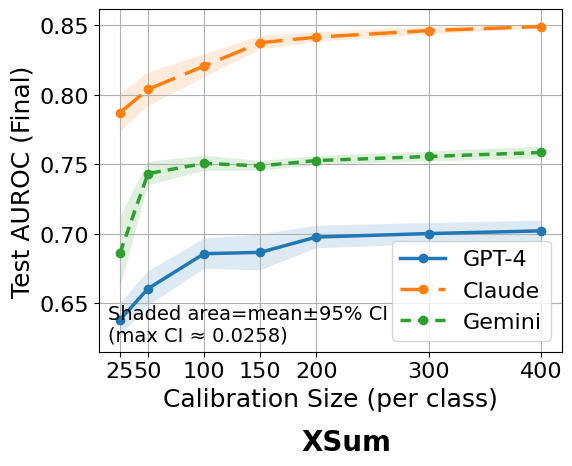

[using] XSum/GPT-4: /content/drive/MyDrive/GPT-4_news_summary.csv
[using] XSum/Claude: /content/drive/MyDrive/claude_news_summary.csv
[using] XSum/Gemini: /content/drive/MyDrive/gemini_news_summary.csv
[saved] /content/drive/MyDrive/plot_XSum_fusion3.png


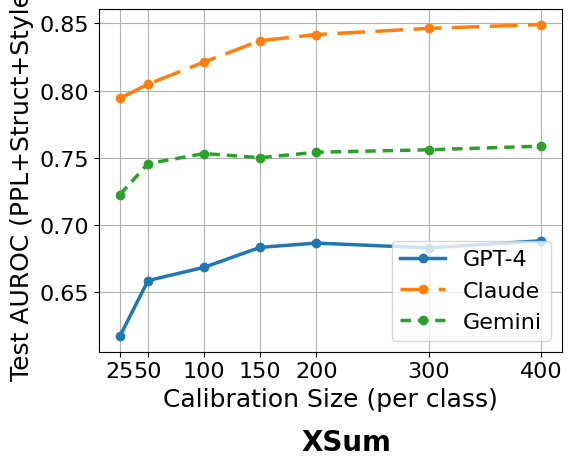

[using] XSum/GPT-4: /content/drive/MyDrive/GPT-4_news_summary.csv
[using] XSum/Claude: /content/drive/MyDrive/claude_news_summary.csv
[using] XSum/Gemini: /content/drive/MyDrive/gemini_news_summary.csv
[saved] /content/drive/MyDrive/plot_XSum_ci_width.png


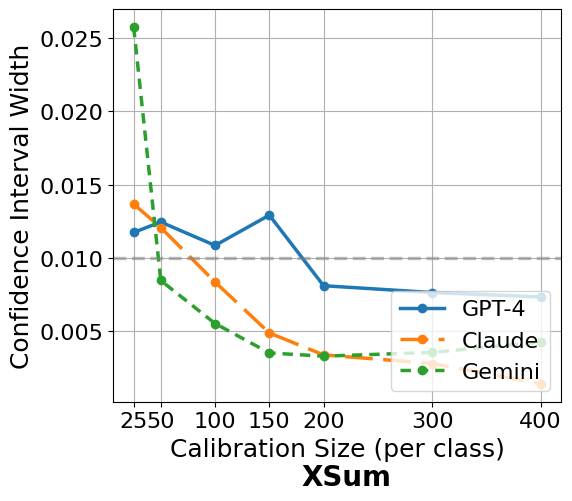

[using] Arxiv/GPT-4: /content/drive/MyDrive/GPT-4_academic_summary.csv
[using] Arxiv/Claude: /content/drive/MyDrive/claude_academic_summary.csv
[using] Arxiv/Gemini: /content/drive/MyDrive/gemini_academic_summary.csv
[saved] /content/drive/MyDrive/plot_Arxiv_final_ci.png


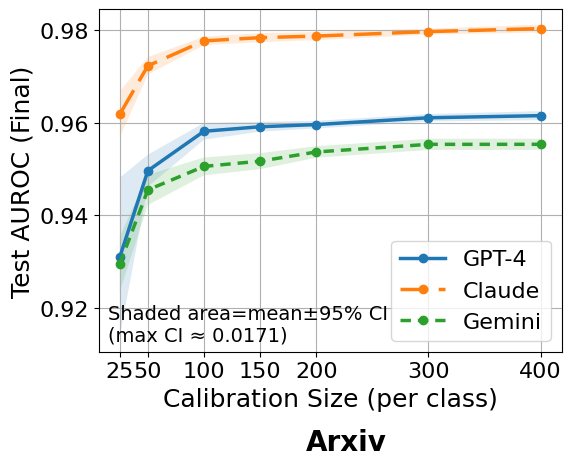

[using] Arxiv/GPT-4: /content/drive/MyDrive/GPT-4_academic_summary.csv
[using] Arxiv/Claude: /content/drive/MyDrive/claude_academic_summary.csv
[using] Arxiv/Gemini: /content/drive/MyDrive/gemini_academic_summary.csv
[saved] /content/drive/MyDrive/plot_Arxiv_fusion3.png


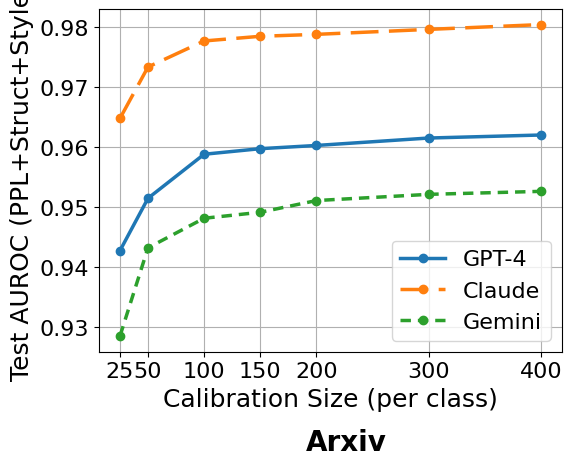

[using] Arxiv/GPT-4: /content/drive/MyDrive/GPT-4_academic_summary.csv
[using] Arxiv/Claude: /content/drive/MyDrive/claude_academic_summary.csv
[using] Arxiv/Gemini: /content/drive/MyDrive/gemini_academic_summary.csv
[saved] /content/drive/MyDrive/plot_Arxiv_ci_width.png


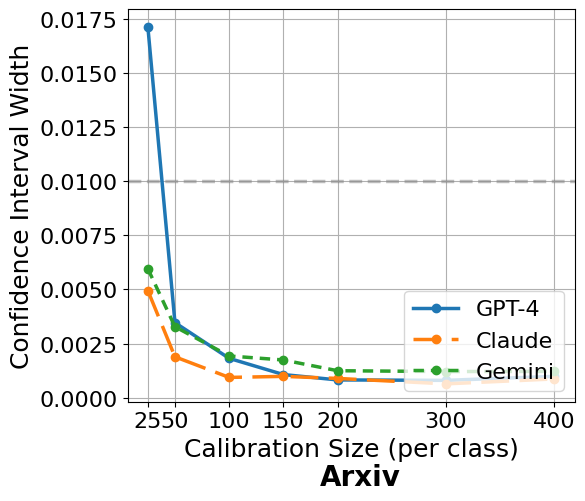

[using] WritingPrompt/GPT-4: /content/drive/MyDrive/GPT-4_story_summary.csv
[using] WritingPrompt/Claude: /content/drive/MyDrive/claude_story_summary.csv
[using] WritingPrompt/Gemini: /content/drive/MyDrive/gemini_story_summary.csv
[saved] /content/drive/MyDrive/plot_WritingPrompt_final_ci.png


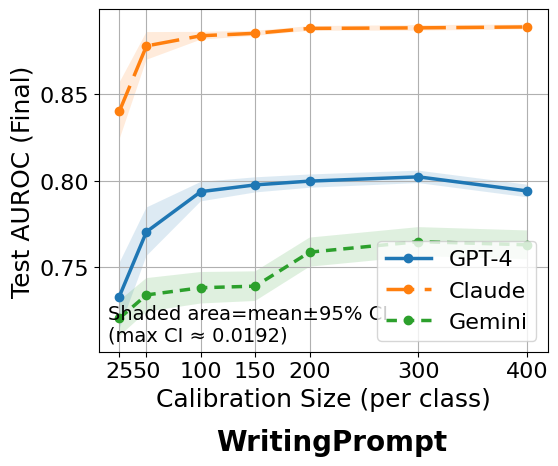

[using] WritingPrompt/GPT-4: /content/drive/MyDrive/GPT-4_story_summary.csv
[using] WritingPrompt/Claude: /content/drive/MyDrive/claude_story_summary.csv
[using] WritingPrompt/Gemini: /content/drive/MyDrive/gemini_story_summary.csv
[saved] /content/drive/MyDrive/plot_WritingPrompt_fusion3.png


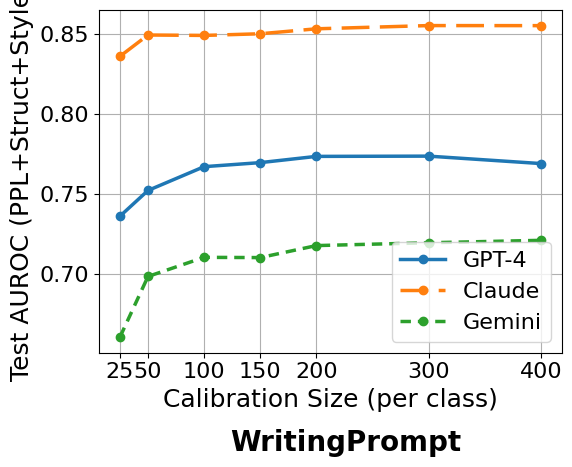

[using] WritingPrompt/GPT-4: /content/drive/MyDrive/GPT-4_story_summary.csv
[using] WritingPrompt/Claude: /content/drive/MyDrive/claude_story_summary.csv
[using] WritingPrompt/Gemini: /content/drive/MyDrive/gemini_story_summary.csv
[saved] /content/drive/MyDrive/plot_WritingPrompt_ci_width.png


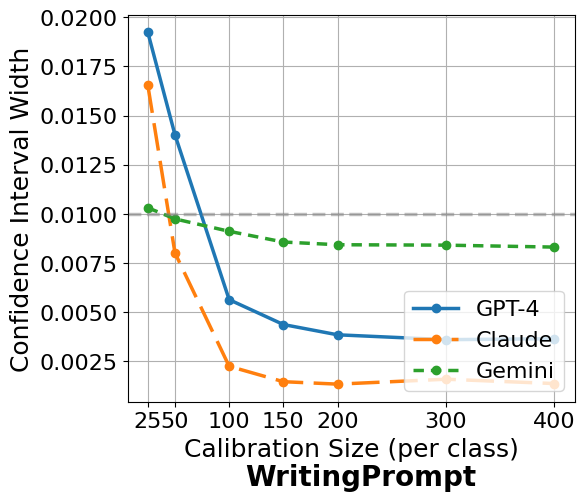

Detected summary files:
 - GPT-4_academic_summary.csv
 - GPT-4_news_summary.csv
 - GPT-4_story_summary.csv
 - claude_academic_summary.csv
 - claude_news_summary.csv
 - claude_story_summary.csv
 - gemini_academic_summary.csv
 - gemini_news_summary.csv
 - gemini_story_summary.csv
[using] XSum/GPT-4: /content/drive/MyDrive/GPT-4_news_summary.csv
[using] XSum/Claude: /content/drive/MyDrive/claude_news_summary.csv
[using] XSum/Gemini: /content/drive/MyDrive/gemini_news_summary.csv
[saved] /content/drive/MyDrive/plot_XSum_final_ci.png


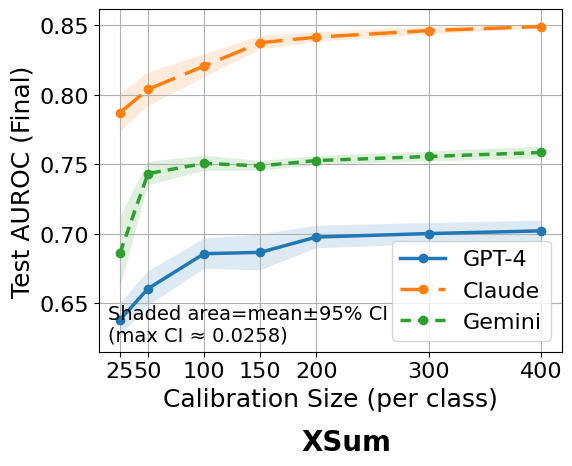

[using] XSum/GPT-4: /content/drive/MyDrive/GPT-4_news_summary.csv
[using] XSum/Claude: /content/drive/MyDrive/claude_news_summary.csv
[using] XSum/Gemini: /content/drive/MyDrive/gemini_news_summary.csv
[saved] /content/drive/MyDrive/plot_XSum_fusion3.png


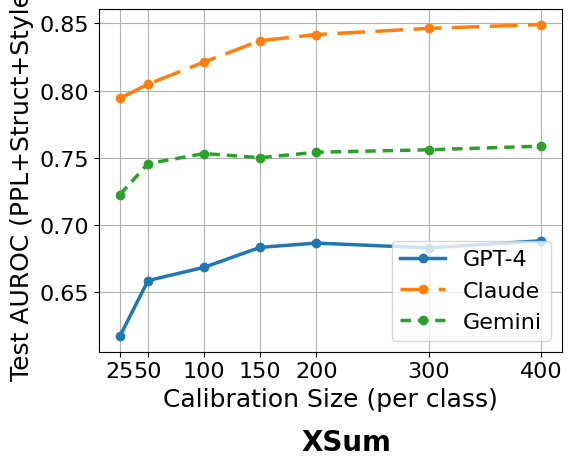

[using] Arxiv/GPT-4: /content/drive/MyDrive/GPT-4_academic_summary.csv
[using] Arxiv/Claude: /content/drive/MyDrive/claude_academic_summary.csv
[using] Arxiv/Gemini: /content/drive/MyDrive/gemini_academic_summary.csv
[saved] /content/drive/MyDrive/plot_Arxiv_final_ci.png


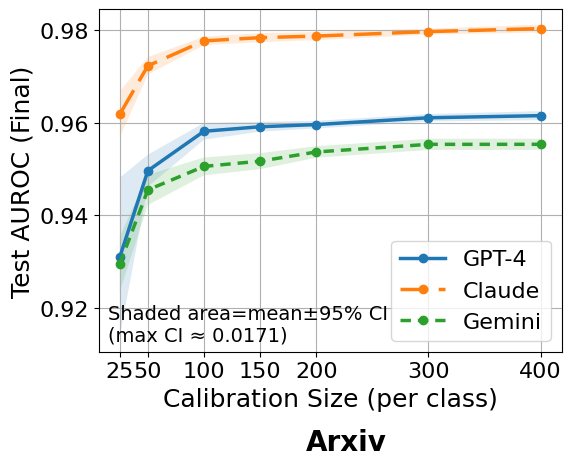

[using] Arxiv/GPT-4: /content/drive/MyDrive/GPT-4_academic_summary.csv
[using] Arxiv/Claude: /content/drive/MyDrive/claude_academic_summary.csv
[using] Arxiv/Gemini: /content/drive/MyDrive/gemini_academic_summary.csv
[saved] /content/drive/MyDrive/plot_Arxiv_fusion3.png


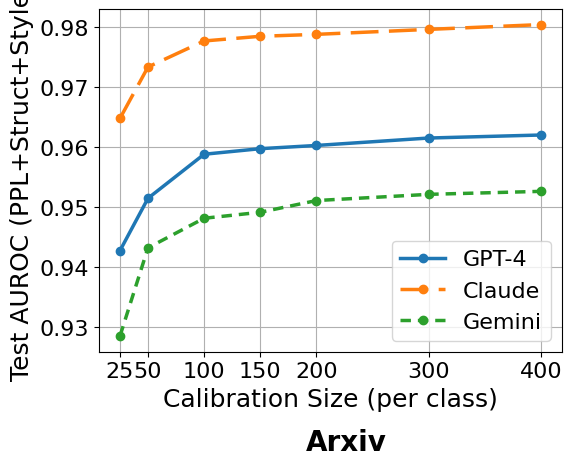

[using] WritingPrompt/GPT-4: /content/drive/MyDrive/GPT-4_story_summary.csv
[using] WritingPrompt/Claude: /content/drive/MyDrive/claude_story_summary.csv
[using] WritingPrompt/Gemini: /content/drive/MyDrive/gemini_story_summary.csv
[saved] /content/drive/MyDrive/plot_WritingPrompt_final_ci.png


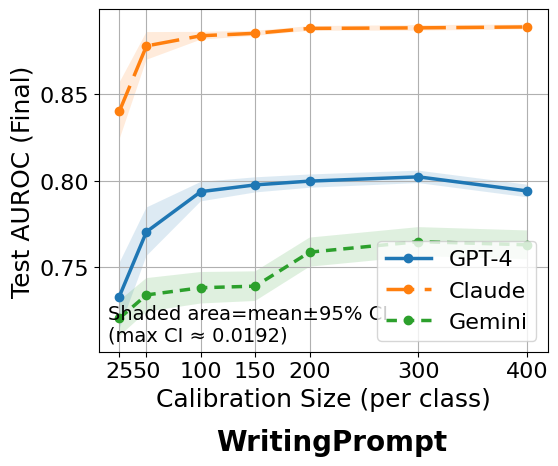

[using] WritingPrompt/GPT-4: /content/drive/MyDrive/GPT-4_story_summary.csv
[using] WritingPrompt/Claude: /content/drive/MyDrive/claude_story_summary.csv
[using] WritingPrompt/Gemini: /content/drive/MyDrive/gemini_story_summary.csv
[saved] /content/drive/MyDrive/plot_WritingPrompt_fusion3.png


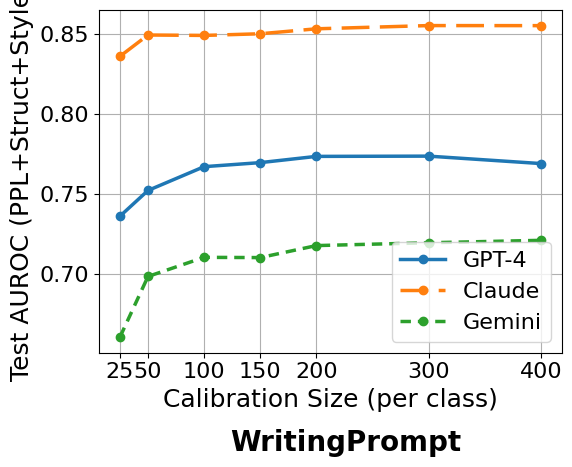

In [ ]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Global Plot Style 
# =========================
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 2.5,
})

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# =========================
# Config
# =========================
SUMMARY_DIR = "/content/drive/MyDrive/"
DOMAINS = ["XSum", "Arxiv", "WritingPrompt"]
MODELS = ["GPT-4", "Claude", "Gemini"]

LINESTYLES = {
    "GPT-4": "solid",
    "Gemini": (0, (3, 2)),
    "Claude": (0, (8, 3)),
}

DOMAIN_ALIASES = {
    "XSum": ["news"],
    "Arxiv": ["academic", "arxiv", "Arxiv", "arXiv", "XSum", "XSum"],
    "WritingPrompt": ["story"],
}

MODEL_ALIASES = {
    "GPT-4": ["GPT-4", "GPT4", "gpt4", "gpt-4", "Gpt4", "gpt_4", "GPT_4"],
    "Claude": ["claude", "Claude"],
    "Gemini": ["gemini", "Gemini"],
}

# =========================
# Helpers
# =========================
def list_summary_files(summary_dir: str):
    if not os.path.exists(summary_dir):
        raise FileNotFoundError(f"SUMMARY_DIR not found: {summary_dir}")
    return [f for f in os.listdir(summary_dir)
            if f.endswith(".csv") and "summary" in f.lower()]

def find_summary_file(domain: str, model: str,
                      summary_dir: str = SUMMARY_DIR) -> str:
    files = list_summary_files(summary_dir)
    domain_keys = DOMAIN_ALIASES.get(domain, [domain])
    model_keys = MODEL_ALIASES.get(model, [model])

    candidates = []
    for fn in files:
        low = fn.lower()
        if "summary" not in low:
            continue
        has_domain = any(d.lower() in low for d in domain_keys)
        has_model = any(m.lower() in low for m in model_keys)
        if has_domain and has_model:
            candidates.append(fn)

    if len(candidates) == 0:
        avail = "\n  - " + "\n  - ".join(sorted(files)) if files else " (none)"
        raise FileNotFoundError(
            f"Cannot find summary CSV for domain='{domain}', model='{model}'.\n"
            f"Available summary files:{avail}"
        )

    candidates = sorted(candidates, key=lambda x: (len(x), x.lower()))
    return os.path.join(summary_dir, candidates[0])

def load_summary(domain: str, model: str):
    path = find_summary_file(domain, model, SUMMARY_DIR)
    print(f"[using] {domain}/{model}: {path}")

    df = pd.read_csv(path)

    if "calib_per_class" not in df.columns:
        raise ValueError(f"'calib_per_class' missing in {path}")

    df = df.sort_values("calib_per_class").reset_index(drop=True)
    df["calib_per_class"] = df["calib_per_class"].astype(int)

    return df

# =========================
# Plotting
# =========================
def plot_domain_final_with_ci(domain: str, save: bool = True):

    plt.figure(figsize=(6, 5))

    all_x = set()
    max_ci = 0.0

    for model in MODELS:
        df = load_summary(domain, model)

        if "auc_test_final_mean" not in df.columns:
            raise ValueError("auc_test_final_mean missing")

        x = df["calib_per_class"].values
        y = df["auc_test_final_mean"].values.astype(float)
        all_x |= set(x.tolist())

        if "auc_test_final_ci95_halfwidth" in df.columns:
            ci = df["auc_test_final_ci95_halfwidth"].values.astype(float)
        elif "auc_test_final_std" in df.columns:
            ci = df["auc_test_final_std"].values.astype(float)
        else:
            ci = None

        plt.plot(
            x, y,
            linestyle=LINESTYLES[model],
            marker="o",
            markersize=6,
            label=model
        )

        if ci is not None:
            plt.fill_between(x, y - ci, y + ci, alpha=0.15)
            max_ci = max(max_ci, np.max(ci))

    plt.xlabel("Calibration Size (per class)")
    plt.ylabel("Test AUROC (Final)")

    plt.grid(True)
    plt.legend(loc='lower right')

    plt.xticks(sorted(all_x))

    if max_ci > 0:
        plt.text(
            0.02, 0.02,
            f"Shaded area=mean±95% CI\n(max CI ≈ {max_ci:.4f})",
            transform=plt.gca().transAxes,
            fontsize=14,
            verticalalignment="bottom"
        )

    if save:
        out = os.path.join(SUMMARY_DIR, f"plot_{domain}_final_ci.png")
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"[saved] {out}")
    plt.figtext(0.6, 0.02, f"{domain}",
              ha='center', fontsize=20, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


def plot_domain_fusion3(domain: str, save: bool = True):

    plt.figure(figsize=(6, 5))

    all_x = set()

    for model in MODELS:
        df = load_summary(domain, model)

        if "auc_test_fusion3_mean" not in df.columns:
            raise ValueError("auc_test_fusion3_mean missing")

        x = df["calib_per_class"].values
        y = df["auc_test_fusion3_mean"].values.astype(float)
        all_x |= set(x.tolist())

        plt.plot(
            x, y,
            linestyle=LINESTYLES[model],
            marker="o",
            markersize=6,
            label=model
        )

    plt.xlabel("Calibration Size (per class)")
    plt.ylabel("Test AUROC (Fusion3)")
    plt.grid(True)
    plt.legend(loc='lower right')

    plt.xticks(sorted(all_x))
    plt.figtext(0.6, 0.02, f"{domain}",
              ha='center', fontsize=20, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    if save:
        out = os.path.join(SUMMARY_DIR, f"plot_{domain}_fusion3.png")
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"[saved] {out}")

    plt.show()

def plot_confidence_interval_width(domain: str, save: bool = True):
    """Plot confidence interval width as a function of calibration sample size"""
    plt.figure(figsize=(6, 5))

    all_x = set()

    for model in MODELS:
        df = load_summary(domain, model)

        # Get confidence interval width (half-width or standard deviation)
        if "auc_test_final_ci95_halfwidth" in df.columns:
            ci_width = df["auc_test_final_ci95_halfwidth"].values.astype(float)
            ci_label = "95% CI Half-Width"
        elif "auc_test_final_std" in df.columns:
            ci_width = df["auc_test_final_std"].values.astype(float)
            ci_label = "Standard Deviation"
        else:
            print(f"Warning: No CI/Std for {domain}/{model}")
            continue

        x = df["calib_per_class"].values
        all_x |= set(x.tolist())

        plt.plot(x, ci_width,
                linestyle=LINESTYLES[model],
                marker="o",
                markersize=6,
                label=model)

    plt.xlabel("Calibration Size (per class)")
    plt.ylabel("Confidence Interval Width")

    plt.grid(True)
    plt.legend(loc='lower right')
    plt.xticks(sorted(all_x))

    # Add horizontal reference line
    plt.axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='0.01 threshold')
    plt.figtext(0.6, 0.00, f"{domain}",
          ha='center', fontsize=20, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    if save:
        out = os.path.join(SUMMARY_DIR, f"plot_{domain}_ci_width.png")
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"[saved] {out}")

# =========================
# Run
# =========================
print("Detected summary files:")
for f in sorted(list_summary_files(SUMMARY_DIR)):
    print(" -", f)

for domain in DOMAINS:
    plot_domain_final_with_ci(domain)
    plot_domain_fusion3(domain)

#Cross-Paragraph Feature Visualization

🔍 开始分析...
✅ 数据加载成功, shape=(2000, 47)


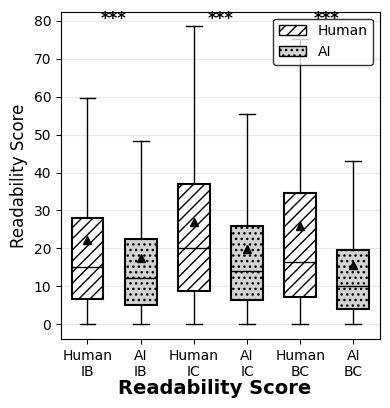


Readability Score - 段间差异统计
  Human IB: mean=22.1740, std=26.9506, N=1000
  AI IB: mean=17.4786, std=20.1883, N=1000
  Human IC: mean=27.0871, std=25.9595, N=1000
  AI IC: mean=19.7060, std=20.9690, N=1000
  Human BC: mean=25.9487, std=29.3810, N=1000
  AI BC: mean=15.6490, std=21.8061, N=1000
  IB Human vs AI: p=0.0000 ***
  IC Human vs AI: p=0.0000 ***
  BC Human vs AI: p=0.0000 ***


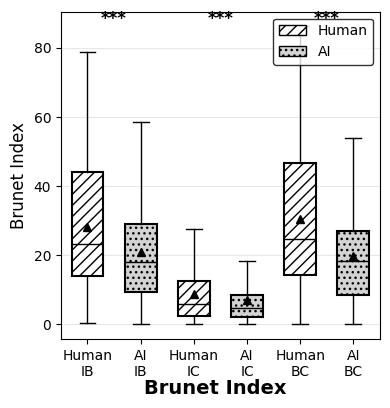


Brunet Index - 段间差异统计
  Human IB: mean=28.2653, std=18.8637, N=807
  AI IB: mean=20.8660, std=16.0804, N=903
  Human IC: mean=8.8818, std=8.9416, N=807
  AI IC: mean=7.1250, std=9.1122, N=903
  Human BC: mean=30.3826, std=20.1684, N=807
  AI BC: mean=19.8856, std=14.5364, N=903
  IB Human vs AI: p=0.0000 ***
  IC Human vs AI: p=0.0001 ***
  BC Human vs AI: p=0.0000 ***


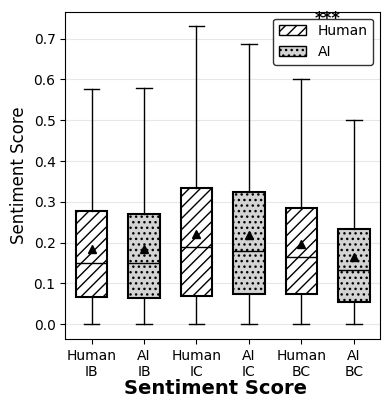


Sentiment Score - 段间差异统计
  Human IB: mean=0.1833, std=0.1480, N=957
  AI IB: mean=0.1848, std=0.1579, N=929
  Human IC: mean=0.2223, std=0.1870, N=957
  AI IC: mean=0.2188, std=0.1880, N=929
  Human BC: mean=0.1967, std=0.1566, N=957
  AI BC: mean=0.1657, std=0.1485, N=929
  IB Human vs AI: p=0.8337 ns
  IC Human vs AI: p=0.6863 ns
  BC Human vs AI: p=0.0000 ***


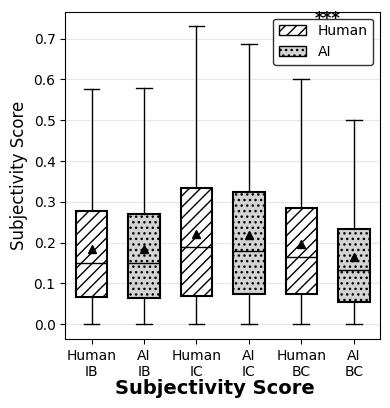


Subjectivity Score - 段间差异统计
  Human IB: mean=0.1833, std=0.1480, N=957
  AI IB: mean=0.1848, std=0.1579, N=929
  Human IC: mean=0.2223, std=0.1870, N=957
  AI IC: mean=0.2188, std=0.1880, N=929
  Human BC: mean=0.1967, std=0.1566, N=957
  AI BC: mean=0.1657, std=0.1485, N=929
  IB Human vs AI: p=0.8337 ns
  IC Human vs AI: p=0.6863 ns
  BC Human vs AI: p=0.0000 ***


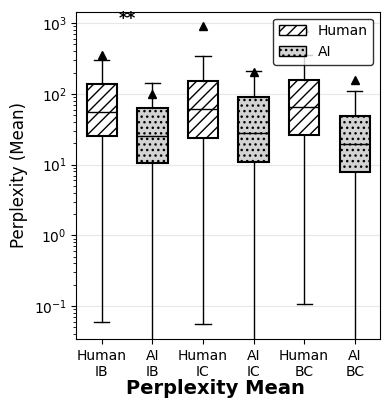


Perplexity Mean - 段间差异统计
  Human IB: mean=350.2938, std=2470.9185, N=877
  AI IB: mean=99.4528, std=755.2780, N=911
  Human IC: mean=896.5394, std=12092.9294, N=877
  AI IC: mean=202.4456, std=2202.0042, N=911
  Human BC: mean=842.0222, std=12024.3148, N=877
  AI BC: mean=154.8782, std=2083.5640, N=911
  IB Human vs AI: p=0.0035 **
  IC Human vs AI: p=0.0889 ns
  BC Human vs AI: p=0.0898 ns


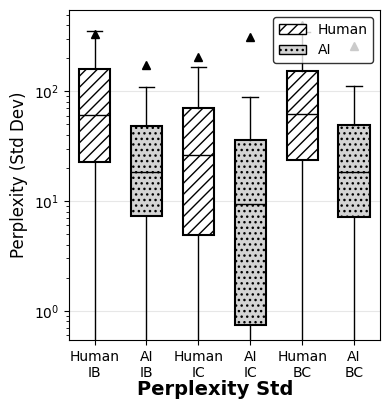


Perplexity Std - 段间差异统计
  Human IB: mean=334.5273, std=2635.3248, N=877
  AI IB: mean=175.5745, std=2635.4610, N=911
  Human IC: mean=207.9783, std=1486.0724, N=877
  AI IC: mean=316.0830, std=5229.7959, N=911
  Human BC: mean=404.0554, std=2911.9885, N=877
  AI BC: mean=260.8500, std=4553.9764, N=911
  IB Human vs AI: p=0.2027 ns
  IC Human vs AI: p=0.5557 ns
  BC Human vs AI: p=0.4306 ns
⚠️ Stopwords Count 没有足够完整样本，跳过


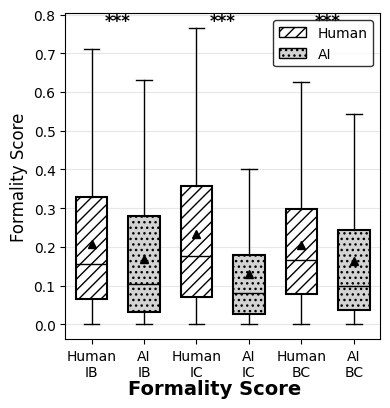


Formality Score - 段间差异统计
  Human IB: mean=0.2084, std=0.1713, N=956
  AI IB: mean=0.1698, std=0.1672, N=930
  Human IC: mean=0.2328, std=0.2006, N=956
  AI IC: mean=0.1304, std=0.1462, N=930
  Human BC: mean=0.2056, std=0.1646, N=956
  AI BC: mean=0.1628, std=0.1624, N=930
  IB Human vs AI: p=0.0000 ***
  IC Human vs AI: p=0.0000 ***
  BC Human vs AI: p=0.0000 ***
⚠️ Name Entity Count 没有足够完整样本，跳过

✅ 所有特征分析完成！
🎉 分析完成！


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

# =======================
# Helper functions
# =======================
def parse_value(x):
    """
    Safely convert value to number:
       - Numbers: return directly
       - Lists: take mean
       - String numbers: convert to float
       - String lists: eval then take mean
    """
    if isinstance(x, (int, float, np.number)):
        return float(x)
    if isinstance(x, (list, np.ndarray)):
        if len(x)==0: return np.nan
        return float(np.mean(x))
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            try:
                lst = eval(x)
                if isinstance(lst, (list, np.ndarray)):
                    return float(np.mean(lst)) if lst else np.nan
            except:
                return np.nan
        try:
            return float(x)
        except:
            return np.nan
    return np.nan

def robust_read_csv(path: str) -> pd.DataFrame:
    for enc in ["utf-8", "utf-8-sig", "gb18030", "gbk", "latin1"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[read] CSV encoding={enc}")
            return df
        except Exception:
            continue
    return pd.read_csv(path, encoding="latin1", errors="ignore")

def smart_read_table(path: str) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(path, engine="openpyxl")
    if ext == ".csv":
        return robust_read_csv(path)
    try:
        return pd.read_excel(path, engine="openpyxl")
    except Exception:
        return robust_read_csv(path)

# =======================
# Core analysis function
# =======================
def plot_feature_comparison(df):
    if 'source' not in df.columns:
        print("❌ 'source' column not found in data!")
        return

    human_df = df[df['source'] == 'human']
    ai_df = df[df['source'] != 'human']

    feature_configs = [
        {'name': 'Readability Score', 'cols': ['intro_readability_score','body_readability_score','conclusion_readability_score'], 'ylabel':'Readability Score', 'log_scale': False},
        {'name': 'Brunet Index', 'cols': ['intro_brunet_index','body_brunet_index','conclusion_brunet_index'], 'ylabel':'Brunet Index', 'log_scale': False},
        {'name': 'Sentiment Score', 'cols': ['intro_polarity_scores','body_polarity_scores','conclusion_polarity_scores','intro_subjectivity_scores','body_subjectivity_scores','conclusion_subjectivity_scores'], 'ylabel':'Sentiment Score', 'log_scale': False},
        {'name': 'Subjectivity Score', 'cols': ['intro_subjectivity_scores','body_subjectivity_scores','conclusion_subjectivity_scores'], 'ylabel':'Subjectivity Score', 'log_scale': False},
        {'name': 'Perplexity Mean', 'cols': ['intro_mean','body_mean','conclusion_mean'], 'ylabel':'Perplexity (Mean)', 'log_scale': True},
        {'name': 'Perplexity Std', 'cols': ['intro_std','body_std','conclusion_std'], 'ylabel':'Perplexity (Std Dev)', 'log_scale': True},
        {'name': 'Stopwords Count', 'cols': ['intro_stopwords_count','body_stopwords_count','conclusion_stopwords_count'], 'ylabel':'Stopwords Count', 'log_scale': False},

        # Additional Formality related features
        {'name': 'Formality Score', 'cols': ['intro_formality_score','body_formality_score','conclusion_formality_score'], 'ylabel':'Formality Score', 'log_scale': False},
        {'name': 'Name Entity Count', 'cols': ['intro_ner_counts','body_ner_counts','conclusion_ner_counts'], 'ylabel':'Entity Count', 'log_scale': False}
    ]

    for feature in feature_configs:
        name = feature['name']
        cols = feature['cols']
        ylabel = feature['ylabel']
        log_scale = feature['log_scale']

        segment_diff = {'human': {'IB': [], 'IC': [], 'BC': []},
                        'ai': {'IB': [], 'IC': [], 'BC': []}}

        def collect_samples(df_subset, label):
            samples = []
            for idx, row in df_subset.iterrows():
                sample = {}
                valid = True
                for col in cols:
                    if col not in row:
                        valid=False
                        break
                    val = parse_value(row[col])
                    if pd.isna(val):
                        valid=False
                        break
                    if 'intro' in col: sample['intro']=val
                    elif 'body' in col: sample['body']=val
                    elif 'conclusion' in col: sample['conclusion']=val
                if valid and len(sample)==3: samples.append(sample)
            for s in samples:
                if 'intro' in s and 'body' in s: segment_diff[label]['IB'].append(abs(s['intro']-s['body']))
                if 'intro' in s and 'conclusion' in s: segment_diff[label]['IC'].append(abs(s['intro']-s['conclusion']))
                if 'body' in s and 'conclusion' in s: segment_diff[label]['BC'].append(abs(s['body']-s['conclusion']))
            return len(samples)

        n_human = collect_samples(human_df, 'human')
        n_ai = collect_samples(ai_df, 'ai')

        if n_human==0 or n_ai==0:
            print(f"⚠️ {name} insufficient complete samples, skipped")
            continue

        fig, ax = plt.subplots(figsize=(4,4))
        #fig.suptitle(f'{name} - Cross-Segment Differences', fontsize=16, fontweight='bold', color='black', y=1.02)

        diff_data = []
        diff_labels = []
        for dt in ['IB','IC','BC']:
            if segment_diff['human'][dt]:
                diff_data.append(segment_diff['human'][dt])
                diff_labels.append(f'Human\n{dt}')
            if segment_diff['ai'][dt]:
                diff_data.append(segment_diff['ai'][dt])
                diff_labels.append(f'AI\n{dt}')

        positions = np.arange(len(diff_data))
        box = ax.boxplot(diff_data, positions=positions, labels=diff_labels,
                         patch_artist=True, showmeans=True, showfliers=False, widths=0.6)

        for i, patch in enumerate(box['boxes']):
            if 'Human' in diff_labels[i]:
                patch.set_facecolor('white')
                patch.set_hatch('///')
            else:
                patch.set_facecolor('lightgray')
                patch.set_hatch('...')
            patch.set_edgecolor('black')
            patch.set_linewidth(1.5)

        for element in ['medians','means','whiskers','caps']:
            if element in box:
                for line in box[element]:
                    line.set_color('black')
        if 'means' in box:
            for m in box['means']:
                m.set_markerfacecolor('black')
                m.set_markeredgecolor('black')

        ax.set_ylabel(ylabel, fontsize=12, color='black')
        ax.tick_params(axis='x', colors='black')
        ax.tick_params(axis='y', colors='black')
        ax.yaxis.label.set_color('black')
        if log_scale: ax.set_yscale('log')

        ax.grid(True, alpha=0.3, axis='y')
        for spine in ax.spines.values(): spine.set_color('black')

        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='white', edgecolor='black', hatch='///', label='Human'),
                           Patch(facecolor='lightgray', edgecolor='black', hatch='...', label='AI')]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, edgecolor='black')
        fig.text(0.55, 0.00, f"{name}",
        ha='center', fontsize=14, fontweight='bold', color='black')

        # =======================
        # Add significance asterisks to the plot
        # =======================
        # Draw boxplot (keep unchanged)


        # Get current y-axis range (but not modify)
        y_min, y_max = ax.get_ylim()

        for i, dt in enumerate(['IB','IC','BC']):
            h_data = segment_diff['human'][dt]
            a_data = segment_diff['ai'][dt]
            if h_data and a_data:
                t, p = stats.ttest_ind(h_data, a_data)
                sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
                if sig:
                    # Find positions of Human and AI
                    h_pos = i*2    # Human at even index
                    a_pos = i*2+1  # AI at odd index

                    # ===== Important modification =====
                    # Use relative coordinates: y fixed at 95% of chart height
                    # transform=ax.transAxes means using relative coordinates (0-1)
                    ax.text((h_pos+a_pos)/2, 0.95, sig,
                            ha='center', va='bottom',
                            fontsize=12, color='black', fontweight='bold',
                            transform=ax.get_xaxis_transform())  # x: data coordinates, y: relative coordinates


        plt.tight_layout()
        plt.show()

        # Statistics
        print(f"\n{name} - Cross-segment difference statistics")
        for dt in ['IB','IC','BC']:
            if segment_diff['human'][dt]:
                print(f"  Human {dt}: mean={np.mean(segment_diff['human'][dt]):.4f}, std={np.std(segment_diff['human'][dt]):.4f}, N={len(segment_diff['human'][dt])}")
            if segment_diff['ai'][dt]:
                print(f"  AI {dt}: mean={np.mean(segment_diff['ai'][dt]):.4f}, std={np.std(segment_diff['ai'][dt]):.4f}, N={len(segment_diff['ai'][dt])}")

        for dt in ['IB','IC','BC']:
            h_data = segment_diff['human'][dt]
            a_data = segment_diff['ai'][dt]
            if h_data and a_data:
                t, p = stats.ttest_ind(h_data, a_data)
                sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
                print(f"  {dt} Human vs AI: p={p:.4f} {sig}")

    print("\n✅ All feature analyses completed!")

# =======================
# Main function
# =======================
def main_analysis(df_path):
    print("🔍 Starting analysis...")
    try:
        df = smart_read_table(df_path)
        print(f"✅ Data loaded successfully, shape={df.shape}")
    except Exception as e:
        print(f"❌ Data loading failed: {e}")
        return
    plot_feature_comparison(df)
    print("🎉 Analysis completed!")

# =======================
# Execution
# =======================
if __name__=="__main__":
    data_path = '/content/M4_modified.xlsx'  # Change to your data path
    main_analysis(data_path)

🔍 开始分析...
[read] CSV encoding=utf-8
✅ 数据加载成功, shape=(2000, 47)
数据列: ['source', 'text', 'label', 'intro', 'body', 'conclusion', 'split_method', 'intro_tokens', 'body_tokens', 'conclusion_tokens', 'total_tokens_3part', 'intro_brunet_index', 'body_brunet_index', 'conclusion_brunet_index', 'intro_readability_score', 'body_readability_score', 'conclusion_readability_score', 'intro_pos_tag_counts', 'body_pos_tag_counts', 'conclusion_pos_tag_counts', 'intro_ner_counts', 'body_ner_counts', 'conclusion_ner_counts', 'intro_stopwords_count', 'body_stopwords_count', 'conclusion_stopwords_count', 'intro_polarity_scores', 'intro_subjectivity_scores', 'intro_pos_wc', 'intro_neg_wc', 'body_polarity_scores', 'body_subjectivity_scores', 'body_pos_wc', 'body_neg_wc', 'conclusion_polarity_scores', 'conclusion_subjectivity_scores', 'conclusion_pos_wc', 'conclusion_neg_wc', 'intro_formality_score', 'body_formality_score', 'conclusion_formality_score', 'intro_mean', 'intro_std', 'body_mean', 'body_std', 'con

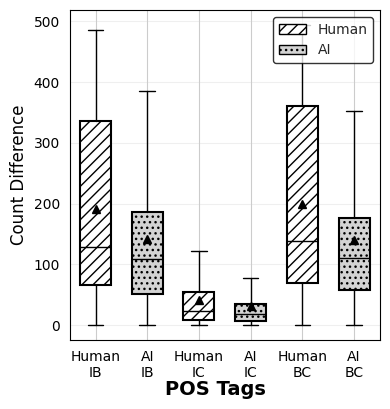


处理 NER Entities - ner_counts:
  Human有效样本数: 1000
  AI有效样本数: 1000

📊 NER Entities - ner_counts 段间差异统计
  Intro-Body (IB):
    Human: mean=8.7260, std=11.5316, N=1000
    AI: mean=6.8560, std=8.4736, N=1000
    Human vs AI: p=0.0012 **
  Intro-Conclusion (IC):
    Human: mean=2.9600, std=5.3304, N=1000
    AI: mean=2.8890, std=5.0920, N=1000
    Human vs AI: p=0.3359 ns
  Body-Conclusion (BC):
    Human: mean=9.2800, std=11.9009, N=1000
    AI: mean=6.5050, std=8.4553, N=1000
    Human vs AI: p=0.0000 ***


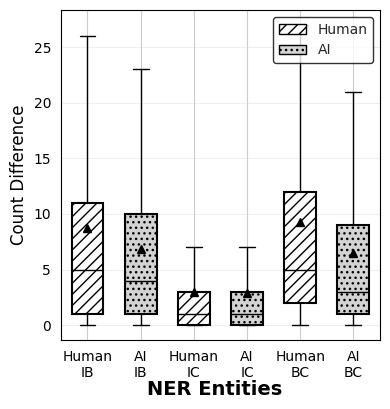


处理 Stopwords - stopwords_count:
  跳过了 177 行（包含空值）
  跳过了 90 行（包含空值）
  Human有效样本数: 823
  AI有效样本数: 910

📊 Stopwords - stopwords_count 段间差异统计
  Intro-Body (IB):
    Human: mean=80.7716, std=68.4274, N=823
    AI: mean=62.7934, std=54.2569, N=910
    Human vs AI: p=0.0000 ***
  Intro-Conclusion (IC):
    Human: mean=18.3001, std=24.4292, N=823
    AI: mean=13.3473, std=18.5325, N=910
    Human vs AI: p=0.0007 ***
  Body-Conclusion (BC):
    Human: mean=83.8153, std=70.0992, N=823
    AI: mean=60.4703, std=53.1655, N=910
    Human vs AI: p=0.0000 ***


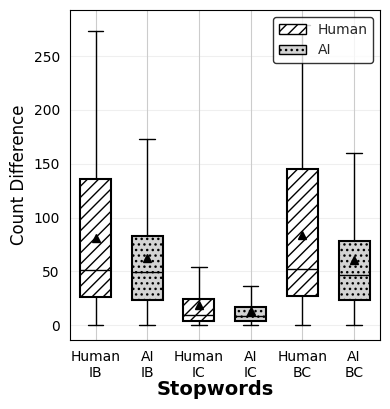


处理 Formality - formality:
  跳过了 44 行（包含空值）
  跳过了 70 行（包含空值）
  Human有效样本数: 956
  AI有效样本数: 930

📊 Formality - formality 段间差异统计
  Intro-Body (IB):
    Human: mean=0.2084, std=0.1714, N=956
    AI: mean=0.1698, std=0.1673, N=930
    Human vs AI: p=0.0000 ***
  Intro-Conclusion (IC):
    Human: mean=0.2328, std=0.2007, N=956
    AI: mean=0.1304, std=0.1462, N=930
    Human vs AI: p=0.0000 ***
  Body-Conclusion (BC):
    Human: mean=0.2056, std=0.1647, N=956
    AI: mean=0.1628, std=0.1625, N=930
    Human vs AI: p=0.0000 ***


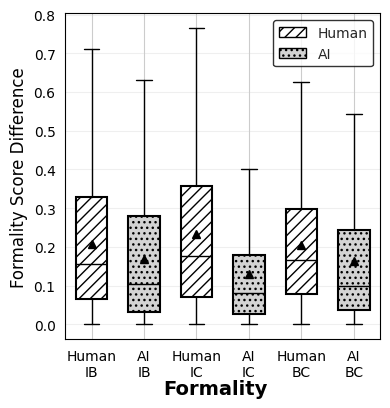

🎉 分析完成！


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import ast
import warnings
import os
warnings.filterwarnings('ignore')

# =======================
# Configure plot style
# =======================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# =======================
# Helper functions
# =======================
def robust_read_csv(path: str) -> pd.DataFrame:
    for enc in ["utf-8", "utf-8-sig", "gb18030", "gbk", "latin1"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[read] CSV encoding={enc}")
            return df
        except Exception:
            continue
    return pd.read_csv(path, encoding="latin1", errors="ignore")

def smart_read_table(path: str) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(path, engine="openpyxl")
    if ext == ".csv":
        return robust_read_csv(path)
    try:
        return pd.read_excel(path, engine="openpyxl")
    except Exception:
        return robust_read_csv(path)

def parse_dict_string(dict_str):
    """Safely parse dictionary string"""
    try:
        if isinstance(dict_str, str):
            return ast.literal_eval(dict_str)
        elif isinstance(dict_str, dict):
            return dict_str
    except:
        return {}
    return {}

def parse_string_list(list_str):
    """Safely parse string list (for formality features)"""
    try:
        # Check empty value
        if list_str is None or pd.isna(list_str):
            return None

        if isinstance(list_str, str):
            # Check empty string
            if not list_str.strip() or list_str.strip() == '[]':
                return None

            # Try to convert string to list
            if list_str.startswith('[') and list_str.endswith(']'):
                try:
                    parsed = ast.literal_eval(list_str)
                    if isinstance(parsed, list):
                        valid_numbers = [float(x) for x in parsed if x is not None]
                        return np.mean(valid_numbers) if valid_numbers else None
                except:
                    # If ast.literal_eval fails, try alternative method
                    # Handle format like '[0.99, 0.92, 0.99]'
                    clean_str = list_str.strip('[]').replace(' ', '')
                    numbers = [float(x) for x in clean_str.split(',') if x.strip()]
                    return np.mean(numbers) if numbers else None
            else:
                # If single number, return directly
                try:
                    return float(list_str)
                except:
                    return None
        elif isinstance(list_str, (list, tuple)):
            # If list, compute mean
            valid_numbers = [float(x) for x in list_str if x is not None]
            return np.mean(valid_numbers) if valid_numbers else None
        elif isinstance(list_str, (int, float)):
            return float(list_str)
    except Exception as e:
        print(f"Error parsing list: {list_str}, error: {e}")
        return None
    return None

# =======================
# Core analysis function
# =======================
def plot_dictionary_feature_analysis(df, base_feature, category_name):
    """Analyze dictionary features (POS, NER, Stopwords) or list features (Formality)"""
    if 'source' not in df.columns:
        print("❌ 'source' column not found in data!")
        return

    human_df = df[df['source']=='human']
    ai_df = df[df['source']!='human']

    # Determine column names based on feature type
    if base_feature == 'formality':
        # formality feature column names are *_formality_score
        feature_cols = [f"intro_{base_feature}_score", f"body_{base_feature}_score", f"conclusion_{base_feature}_score"]
    else:
        feature_cols = [f"intro_{base_feature}", f"body_{base_feature}", f"conclusion_{base_feature}"]

    existing_cols = [col for col in feature_cols if col in df.columns]

    if len(existing_cols) < 2:
        print(f"⚠️ {base_feature} feature incomplete, skipped")
        print(f"   Expected columns: {feature_cols}")
        print(f"   Existing columns: {existing_cols}")
        return

    # Collect complete samples (automatically skip empty values)
    def collect_samples(df_subset):
        samples = []
        source_data = {'intro':[], 'body':[], 'conclusion':[]}
        skipped_count = 0
        empty_count = 0

        for idx, row in df_subset.iterrows():
            s = {}
            valid_row = True

            for col in feature_cols:
                if col in row:
                    # Check if empty
                    if pd.isna(row[col]):
                        empty_count += 1
                        valid_row = False
                        break

                    # Get value
                    if base_feature == 'formality':
                        # For formality, parse string list and compute mean
                        val = parse_string_list(row[col])
                        if val is None:  # Parsing failed
                            empty_count += 1
                            valid_row = False
                            break
                    else:
                        # Dictionary features need parsing
                        dict_val = parse_dict_string(row[col])
                        if not dict_val:  # Empty dictionary
                            empty_count += 1
                            valid_row = False
                            break
                        val = sum(dict_val.values())

                    if 'intro' in col:
                        s['intro'] = val
                        source_data['intro'].append(val)
                    elif 'body' in col:
                        s['body'] = val
                        source_data['body'].append(val)
                    elif 'conclusion' in col:
                        s['conclusion'] = val
                        source_data['conclusion'].append(val)

            if valid_row and len(s) == 3:  # All three parts valid
                samples.append(s)
            else:
                skipped_count += 1

        if skipped_count > 0:
            print(f"   Skipped {skipped_count} rows (containing empty values)")

        return samples, source_data

    print(f"\nProcessing {category_name} - {base_feature}:")
    human_samples, human_source = collect_samples(human_df)
    ai_samples, ai_source = collect_samples(ai_df)

    print(f"  Human valid samples: {len(human_samples)}")
    print(f"  AI valid samples: {len(ai_samples)}")

    # If not enough samples, skip
    if len(human_samples) < 5 or len(ai_samples) < 5:
        print(f"⚠️ {base_feature} insufficient valid samples, skipping plot")
        return

    # Calculate segment differences
    def calc_segment_diff(samples):
        diff = {'IB':[], 'IC':[], 'BC':[]}
        for s in samples:
            diff['IB'].append(abs(s['intro'] - s['body']))
            diff['IC'].append(abs(s['intro'] - s['conclusion']))
            diff['BC'].append(abs(s['body'] - s['conclusion']))
        return diff

    human_diff = calc_segment_diff(human_samples)
    ai_diff = calc_segment_diff(ai_samples)

    print(f"\n📊 {category_name} - {base_feature} cross-segment difference statistics")

    diff_types = ['IB', 'IC', 'BC']
    diff_names = {'IB': 'Intro-Body', 'IC': 'Intro-Conclusion', 'BC': 'Body-Conclusion'}

    for diff_type in diff_types:
        human_data = human_diff[diff_type]
        ai_data = ai_diff[diff_type]

        if human_data and ai_data:
            # Compute statistics
            human_mean = np.mean(human_data)
            human_std = np.std(human_data, ddof=1)
            human_n = len(human_data)

            ai_mean = np.mean(ai_data)
            ai_std = np.std(ai_data, ddof=1)
            ai_n = len(ai_data)

            # Perform Mann-Whitney U test
            stat, p_value = stats.mannwhitneyu(human_data, ai_data, alternative='two-sided')

            # Determine significance
            if p_value < 0.001:
                sig_mark = '***'
            elif p_value < 0.01:
                sig_mark = '**'
            elif p_value < 0.05:
                sig_mark = '*'
            else:
                sig_mark = 'ns'

            print(f"  {diff_names[diff_type]} ({diff_type}):")
            print(f"    Human: mean={human_mean:.4f}, std={human_std:.4f}, N={human_n}")
            print(f"    AI: mean={ai_mean:.4f}, std={ai_std:.4f}, N={ai_n}")
            print(f"    Human vs AI: p={p_value:.4f} {sig_mark}")

    # =======================
    # Plot - cross-segment difference plot (with mean markers, legend and black frames)
    # =======================
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    # Cross-segment difference plot
    diff_plot_data = []
    diff_labels = []

    # For each difference type, human first then AI
    for label, human_data, ai_data in zip(['IB', 'IC', 'BC'],
                                          [human_diff['IB'], human_diff['IC'], human_diff['BC']],
                                          [ai_diff['IB'], ai_diff['IC'], ai_diff['BC']]):
        if human_data and ai_data:
            diff_plot_data.append(human_data)  # human first
            diff_plot_data.append(ai_data)     # AI second
            diff_labels.append(f"Human\n{label}")
            diff_labels.append(f"AI\n{label}")

    if diff_plot_data:
        positions = np.arange(len(diff_plot_data))
        box = ax.boxplot(diff_plot_data, positions=positions,
                        labels=diff_labels, patch_artist=True,
                        widths=0.6, showfliers=False, showmeans=True)

        # Black and white style: human white with diagonal lines, AI gray with dots
        for i, patch in enumerate(box['boxes']):
            if i % 2 == 0:  # human
                patch.set_facecolor('white')
                patch.set_hatch('///')
            else:            # AI
                patch.set_facecolor('lightgray')
                patch.set_hatch('...')
            patch.set_edgecolor('black')
            patch.set_linewidth(1.5)

        # Set median, mean, whiskers, caps colors to black
        for element in ['medians', 'means', 'whiskers', 'caps']:
            if element in box:
                for line in box[element]:
                    line.set_color('black')

        # Set mean marker style
        if 'means' in box:
            for m in box['means']:
                m.set_markerfacecolor('black')
                m.set_markeredgecolor('black')
                m.set_markersize(6)

        # Set y-axis label
        if base_feature == 'formality':
            ax.set_ylabel("Formality Score Difference", fontsize=12, color='black')
        else:
            ax.set_ylabel("Count Difference", fontsize=12, color='black')

        # Set axis ticks and label colors
        ax.tick_params(axis='x', colors='black')
        ax.tick_params(axis='y', colors='black')
        ax.yaxis.label.set_color('black')

        # Set grid and spines
        ax.grid(True, alpha=0.3, axis='y')
        for spine in ax.spines.values():
            spine.set_color('black')

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='white', edgecolor='black', hatch='///', label='Human'),
            Patch(facecolor='lightgray', edgecolor='black', hatch='...', label='AI')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10,
                 frameon=True, edgecolor='black')
        fig.text(0.55, 0.00, f"{category_name}",
         ha='center', fontsize=14, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

# =======================
# Main function
# =======================
def main_analysis(df_path):
    print("🔍 Starting analysis...")
    try:
        df = smart_read_table(df_path)
        print(f"✅ Data loaded successfully, shape={df.shape}")
        print(f"Data columns: {df.columns.tolist()}")
    except Exception as e:
        print(f"❌ Data loading failed: {e}")
        return

    # Dictionary features + formality feature
    features = [
        ('pos_tag_counts', 'POS Tags'),
        ('ner_counts', 'NER Entities'),
        ('stopwords_count', 'Stopwords'),
    ]

    # Check if formality_score columns exist
    formality_cols = [col for col in df.columns if 'formality_score' in col]
    if formality_cols:
        features.append(('formality', 'Formality'))
        print(f"✅ Found formality_score columns: {formality_cols}")

    for feat, name in features:
        plot_dictionary_feature_analysis(df, feat, name)

    print("🎉 Analysis completed!")

# =======================
# Execution
# =======================
if __name__=="__main__":
    data_path = "/content/mini (1).csv"  # Change to your data path
    main_analysis(data_path)

#Adversarial Text Generation

In [ ]:
# =========================
# 0️⃣ Dependencies + fixed seed
# =========================
import pandas as pd
import random
from tqdm import tqdm

random.seed(42)
tqdm.pandas()

import nltk
from nltk.corpus import wordnet
nltk.download("wordnet")
nltk.download("omw-1.4")

from transformers import MarianMTModel, MarianTokenizer

# =========================
# 1️⃣ Parameters
# =========================
BT_WEIGHT = 3
SYN_WEIGHT = 4
NOISE_WEIGHT = 3

# =========================
# 2️⃣ Load data
# =========================
df = pd.read_excel("/content/drive/MyDrive/human&_claude-story.xlsx")

print("Columns:", df.columns)

df["source"] = df["source"].astype(str)

# =========================
# 3️⃣ Filter AI (Claude) + 300 samples
# =========================
ai_df = df[df["source"].str.lower().str.contains("claude")].copy()

print("Total Claude samples:", len(ai_df))

ai_df = ai_df.sample(n=min(300, len(ai_df)), random_state=42).reset_index(drop=True)

print("Using samples:", len(ai_df))

# =========================
# 4️⃣ Check columns
# =========================
cols = ["intro", "body", "conclusion"]

for c in cols:
    if c not in ai_df.columns:
        raise ValueError(f"❌ Missing column: {c}")

# =========================
# 5️⃣ Load back-translation models (load once only)
# =========================
print("Loading translation models...")

model_en_de = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-de")
tokenizer_en_de = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-de")

model_de_en = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-de-en")
tokenizer_de_en = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-de-en")


def back_translation(text):
    try:
        inputs = tokenizer_en_de(text, return_tensors="pt", truncation=True, max_length=512)
        de = model_en_de.generate(**inputs)
        de_text = tokenizer_en_de.decode(de[0], skip_special_tokens=True)

        inputs = tokenizer_de_en(de_text, return_tensors="pt", truncation=True, max_length=512)
        en = model_de_en.generate(**inputs)
        en_text = tokenizer_de_en.decode(en[0], skip_special_tokens=True)

        return en_text
    except:
        return text

# =========================
# 6️⃣ Synonym attack
# =========================
def synonym_attack(text):
    words = text.split()
    out = []

    for w in words:
        if random.random() < 0.15:
            syns = wordnet.synsets(w)
            if syns:
                lemmas = syns[0].lemma_names()
                if lemmas:
                    w = lemmas[0].replace("_", " ")
        out.append(w)

    return " ".join(out)

# =========================
# 7️⃣ Noise attack
# =========================
def noise_attack(text):
    words = text.split()
    out = []

    for w in words:
        if random.random() < 0.05:
            w = w.lower()
        if random.random() < 0.03:
            w = w + "..."
        out.append(w)

    return " ".join(out)

# =========================
# 8️⃣ Document-level attack (core)
# =========================
def attack_row(row):
    # ⭐ Only one attack type per document
    attack_type = random.choices(
        ["bt", "syn", "noise"],
        weights=[BT_WEIGHT, SYN_WEIGHT, NOISE_WEIGHT]
    )[0]

    if attack_type == "bt":
        f = back_translation
    elif attack_type == "syn":
        f = synonym_attack
    else:
        f = noise_attack

    return pd.Series({
        "intro_text": f(str(row["intro"])),
        "body_text": f(str(row["body"])),
        "conclusion_text": f(str(row["conclusion"]))
    })

# =========================
# 9️⃣ Execute attack (per document)
# =========================
print("\n🚀 Running document-level attack (1:5:4)...")

ai_df[cols] = ai_df.progress_apply(attack_row, axis=1)

# =========================
# 🔟 Output
# =========================
out_df = ai_df[cols]

out_df.to_csv("ai_300_doclevel_154.csv", index=False, encoding="utf-8")

print("\n✅ Done! Saved as ai_300_doclevel_154.csv")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Columns: Index(['source', 'model', 'task', 'original_filename', 'item_index',
       'task_index', 'prompt', 'full_text', 'intro', 'body', 'conclusion',
       'intro_len', 'body_len', 'conclusion_len', 'total_len',
       'segmentation_time', 'intro_brunet_index', 'body_brunet_index',
       'conclusion_brunet_index', 'intro_readability_score',
       'body_readability_score', 'conclusion_readability_score',
       'intro_pos_tag_counts', 'body_pos_tag_counts',
       'conclusion_pos_tag_counts', 'intro_ner_counts', 'body_ner_counts',
       'conclusion_ner_counts', 'intro_stopwords_count',
       'body_stopwords_count', 'conclusion_stopwords_count',
       'intro_polarity_scores', 'intro_subjectivity_scores', 'intro_pos_wc',
       'intro_neg_wc', 'body_polarity_scores', 'body_subjectivity_scores',
       'body_pos_wc', 'body_neg_wc', 'conclusion_polarity_scores',
       'conclusion_subjectivity_scores', 'conclusion_pos_wc',
       'conclusion_neg_wc', 'intro_formality_score', 'body_

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



🚀 Running document-level attack (1:5:4)...


100%|██████████| 300/300 [16:34<00:00,  3.31s/it]


✅ Done! Saved as ai_300_doclevel_154.csv
